---   
 <img align="left" width="75" height="75"  src="https://upload.wikimedia.org/wikipedia/en/c/c8/University_of_the_Punjab_logo.png"> 

<h1 align="center">Department of Data Science</h1>
<h1 align="center">Course: Generative and Agentic AI</h1>

---
<h3><div align="right">Instructor: Muhammad Arif Butt, Ph.D.</div></h3>    

<br><br>
<h1 align="center">Lec-23: Fine-Tuning LLMs - II</h1>

# Learning Agenda of This Notebook

1. Compressing LLMs
2. Why Do We Quantize LLMs?
3. Hands-on Understanding of Memory Footprints of LLMs
4. INT8 Symmetric and Asymmetric Quantization
5. INT4 Symmetric and Asymmetric Quantization
6. Example Questions (INT8 and INT4 Quantization)
7. A Deep Dive into the Working of QLoRA - Quantized Low-Rank Adaptation
8. NF4 (Normal Float 4-bit Quantization)
    - Example Questions (NF4)
9. The Outlier Problem in NF4 and its Solution (**Blockwise NF4**)
    - Example Questions (Blockwise NF4)
10. Storing Too Many fp32 Scale Factors in Blockwise NF4 and its Solution (**Double Quantization**)
    - Example Questions (Double Quantization)
11. What is **Paged Optimization** in QLoRA?
12. Memory Comparison: Full FT vs LoRA only vs QLoRA (7B Model)

# <span style='background :lightgreen' >1. Compressing LLMs</span>

<h3 align="center"><div class="alert alert-success" color=magenta style="margin: 20px"><b>Moore's Law for LLMs</b> states that model performance improves predictably and log-linearly with increases in three factors: <b>data, parameters,</b> and <b>compute</b></h3>
    
<div style="text-align:center;">
    <img src="../images/moores-law-llm.png"
         style="max-width:1000px; width:100%; height:auto; display:inline-block;">
</div>


<h1 align="center"><div class="alert alert-success" color=magenta style="margin: 20px">Reduce model size  without sacrificing performance</h1>

# Three Different Ways to Compress LLMs
### Quantization: [QLoRA](https://arxiv.org/abs/2305.14314), [DoRA](https://arxiv.org/abs/2402.09353), [BitFit](https://arxiv.org/abs/2106.10199), [IA3](https://arxiv.org/abs/2205.05638), [The Era of 1-bit LLMs](https://arxiv.org/pdf/2402.17764)
### Pruning: [To prune or not to prune](https://arxiv.org/pdf/1710.01878)
### Distillation: [Distilling Knowledge in Neural Network](https://arxiv.org/pdf/1503.02531)

<div style="text-align:center;">
    <img src="../images/compressing-llms.png"
         style="max-width:1000px; width:100%; height:auto; display:inline-block;">
</div>

# <span style='background :lightgreen' >2. Why Do We Quantize LLMs? 🤔 </span>
## a. How Integer Values are Stored?
- Integer values are stored as binary representations and the commonly used bit-widths are `int4`, `int8`, `int16`, `int32`, and `int64`
    - **Sign bit** → determines positive or negative value (in signed representations)
    - **Magnitude bits** → store the absolute value of the number
    - **Three main representations** → Sign-Magnitude, 1's Complement, 2's Complement

### Sign-Magnitude
- The MSB (Most Significant Bit) is the sign bit: `0` = positive, `1` = negative
- Remaining bits store the absolute value of the number directly
- Has **two representations of zero**: `0000...0` and `1000...0`
```
┌───┬────────────────────────────────────────────────────────────────┐
│ S │                        Magnitude                               │
│1b │                    (n-1) bits                                  │
└───┴────────────────────────────────────────────────────────────────┘
```
> ⚠️ **Rarely used in modern hardware due to dual-zero ambiguity and complex arithmetic circuits**

### 1's Complement
- Positive numbers are stored as-is in binary
- Negative numbers are obtained by **flipping all bits** of the positive counterpart
- Still has **two representations of zero**: `0000…0` and `1111…1`
```
┌───┬────────────────────────────────────────────────────────────────┐
│ S │                    Flipped Magnitude Bits                      │
│1b │                        (n-1) bits                              │
└───┴────────────────────────────────────────────────────────────────┘
```
> ⚠️ **End-around carry needed during addition; still suffers from dual-zero**

### 2's Complement
- Positive numbers are stored as-is in binary
- Negative numbers are obtained by **flipping all bits then adding 1**
- Has **only one zero** representation: `0000…0`
- This is the **universally adopted standard** in modern CPUs, GPUs, and ML hardware
```
┌───┬────────────────────────────────────────────────────────────────┐
│ S │               Flipped Magnitude Bits + 1                       │
│1b │                        (n-1) bits                              │
└───┴────────────────────────────────────────────────────────────────┘
```
> 💡 **2's complement allows addition and subtraction to use the same hardware circuit**



| Format | Total Bits | Magnitude Bits | Representation | Range (Signed) | Range (Unsigned) | Dual Zero? | Used In |
|---|---|---|---|---|---|---|---|
| int4 | 4 | 3 | Sign-Magnitude | −7 to +7 | — | ✅ Yes | — |
| int4 | 4 | 3 | 1's Complement | −7 to +7 | — | ✅ Yes | — |
| int4 | 4 | 3 | 2's Complement | −8 to +7 | 0 to 15 | ❌ No | LLM Quantization (GPTQ, QLoRA) |
| int8 | 8 | 7 | Sign-Magnitude | −127 to +127 | — | ✅ Yes | — |
| int8 | 8 | 7 | 1's Complement | −127 to +127 | — | ✅ Yes | — |
| int8 | 8 | 7 | 2's Complement | −128 to +127 | 0 to 255 | ❌ No | Model quantization, inference (LLM.int8) |
| int16 | 16 | 15 | Sign-Magnitude | −32,767 to +32,767 | — | ✅ Yes | — |
| int16 | 16 | 15 | 1's Complement | −32,767 to +32,767 | — | ✅ Yes | — |
| int16 | 16 | 15 | 2's Complement | −32,768 to +32,767 | 0 to 65,535 | ❌ No | Audio processing, embeddings |
| int32 | 32 | 31 | Sign-Magnitude | −2,147,483,647 to +2,147,483,647 | — | ✅ Yes | — |
| int32 | 32 | 31 | 1's Complement | −2,147,483,647 to +2,147,483,647 | — | ✅ Yes | — |
| int32 | 32 | 31 | 2's Complement | −2,147,483,648 to +2,147,483,647 | 0 to 4,294,967,295 | ❌ No | General computing, index tensors |
| int64 | 64 | 63 | Sign-Magnitude | −(2⁶³−1) to +(2⁶³−1) | — | ✅ Yes | — |
| int64 | 64 | 63 | 1's Complement | −(2⁶³−1) to +(2⁶³−1) | — | ✅ Yes | — |
| int64 | 64 | 63 | 2's Complement | −2⁶³ to +(2⁶³−1) | 0 to 2⁶⁴−1 | ❌ No | Large index arithmetic, scientific computing |

> **[Arif's YouTube Video on how Integers are Stored?](https://www.youtube.com/watch?v=rb6vaNZf1p8&list=PL7B2bn3G_wfCC2HDSXtMFsskasZ5fdLXz&index=6)**

## b. How Model Weights (floating point values) are Stored?
- Model weights are learned during training and stored as numerical values and the commonly used datatypes are `fp64`, `fp32`, `fp16`, and `bf16`
    - **Sign bit** → determines positive or negative value  
    - **Exponent** → controls the numeric range
    - **Mantissa (Fraction)** → controls the precision

> The exponent field is stored as an unsigned integer, but a fixed bias (2ⁿ⁻¹ − 1) is subtracted from it to recover the true (signed) exponent — this allows representation of both very large and very small numbers without a separate sign bit for the exponent.

### FP64 (Double Precision – 64 bits)
- Provides the highest precision and widest range of all standard floating point formats.
- Used in scientific computing and numerical simulations where accuracy is critical, but rarely used in deep learning due to high memory cost.
```
┌───┬─────────────┬────────────────────────────────────────────────────┐
│ S │  Exponent   │                      Mantissa                      │
│1b │   11 bits   │                      52 bits                       │
└───┴─────────────┴────────────────────────────────────────────────────┘
```

### FP32 (Single Precision – 32 bits)
```
┌───┬──────────┬───────────────────────────────┐
│ S │ Exponent │           Mantissa            │
│1b │  8 bits  │            23 bits            │
└───┴──────────┴───────────────────────────────┘
```

### FP16 (Half Precision – 16 bits)
- Preferred for Inference because it has narrow range and high precision
```
┌───┬─────────┬──────────────┐
│ S │Exponent │   Mantissa   │   
│1b │ 5 bits  │   10 bits    │   
└───┴─────────┴──────────────┘
```

### BF16 (Brain Floating Point – 16 bits)
- It keeps the same 8-bit exponent as fp32, so it can represent the same magnitude of numbers as fp32 without overflow.
- This is why it is preferred for LLM training where gradient magnitudes can vary wildly, even though it is less precise than fp16.
```
┌───┬──────────┬───────────┐
│ S │ Exponent │ Mantissa  │  
│1b │  8 bits  │  7 bits   │  
└───┴──────────┴───────────┘  
```
> 💡 **bf16 sacrifices precision to gain range**

| Format | Total Bits | Sign Bits | Exponent Bits | Mantissa Bits | Significant Decimal Digits ($\text{mantissa bits} \times \log_{10}(2)$) | Approximate Range | Used In |
|---|---|---|---|---|---|---|---|
| fp64 | 64 | 1 | 11 | 52 | 52 × 0.30103 = 15.65 ≈ 15 | ±1.8 × 10³⁰⁸ | Scientific computing |
| fp32 | 32 | 1 | 8 | 23 | 23 × 0.30103 = 6.92  ≈ 7  | ±3.4 × 10³⁸  | Standard training, optimizer states |
| fp16 | 16 | 1 | 5 | 10 | 10 × 0.30103 = 3.01  ≈ 3  | ±6.5 × 10⁴   | GPU training (mixed precision) |
| bf16 | 16 | 1 | 8 | 7  | 7  × 0.30103 = 2.11  ≈ 2  | ±3.4 × 10³⁸  | Google TPUs, modern LLM training |



> **[Arif's YouTube Video on how Floating Point Values are Stored?](https://www.youtube.com/watch?v=4COgD6DM9a8&list=PL7B2bn3G_wfCC2HDSXtMFsskasZ5fdLXz&index=7)**

## c. Understanding Quantization
<h2 align="center"><div class="alert alert-success" color=magenta style="margin: 20px">Quantization is the process of reducing the numerical precision of a model's weights (from fp32/16 to 8/4-bit integers)</h2>


<h2 align="center"><div class="alert alert-success" color=magenta style="margin: 20px">This dramatically reduces the model's memory footprint with minimal loss in quality and makes fine-tuning possible on consumer hardware</h2>

<img align="right" width="800"  src="../images/quant01.png"  > 

- Think of it like compressing a high-resolution image into a smaller file size — you lose a tiny bit of quality, but the file becomes dramatically smaller and faster to work with
- In the context of LLMs, quantization is what makes it possible to **run and fine-tune billion-parameter models on consumer hardware** that would otherwise be completely out of reach
- Visit: [BitsAndBytes Library](https://github.com/TimDettmers/bitsandbytes)


## d. Why Do We Quantize LLMs?

- To understand why quantization is necessary, let's walk through a concrete memory calculation for a **10 billion parameter model** during fine-tuning with Adam optimizer:

### FULL FINE-TUNING — 10B Model Memory Breakdown with Adam Optimizer:
```
──────────────────────────────────────────────────────────────────────────────────
Component                      │ Precision │ Bytes/param │ Parameters │ Total Memory
───────────────────────────────┼───────────┼─────────────┼────────────┼─────────────
1. Model Weights               │ fp16      │ 2 bytes     │ 10B        │  20.0 GB
2. Gradients                   │ fp16      │ 2 bytes     │ 10B        │  20.0 GB
3. fp32 Master Weights (Adam)  │ fp32      │ 4 bytes     │ 10B        │  40.0 GB
4. Adam Momentum (m)           │ fp32      │ 4 bytes     │ 10B        │  40.0 GB
5. Adam Variance  (v)          │ fp32      │ 4 bytes     │ 10B        │  40.0 GB
──────────────────────────────────────────────────────────────────────────────────
TOTAL                                                                 │ 160.0 GB
──────────────────────────────────────────────────────────────────────────────────
Requires: 2× A100 80GB GPUs minimum — impractical for most people!
```

### LoRA FINE-TUNING (r = 16, 10B model) Memory Breakdown with Adam Optimizer:
- A 10B model typically has ~32 transformer layers
- Per layer, LoRA is applied to Q, K, V, O projection matrices (4 matrices)
- Each LoRA adapter adds: A (4096×16) + B (16×4096) = 65,536 + 65,536 = **131,072 params per matrix**
- Total LoRA params: 32 layers × 4 matrices × 131,072 = **~16.8M params ≈ 0.017B**
- This is roughly **0.17% of total parameters** — everything else is frozen

```
──────────────────────────────────────────────────────────────────────────────────────────
Component                      │ Precision │ Bytes/param │ Parameters    │ Total Memory
───────────────────────────────┼───────────┼─────────────┼───────────────┼──────────────
1. Model Weights (frozen)      │ fp16      │ 2 bytes     │ 10B           │  20.00 GB
2. LoRA Adapter Weights        │ fp16      │ 2 bytes     │ ~16.8M (0.17%)│   0.03 GB
3. Gradients (LoRA only)       │ fp16      │ 2 bytes     │ ~16.8M        │   0.03 GB
4. fp32 Master Weights (Adam)  │ fp32      │ 4 bytes     │ ~16.8M        │   0.07 GB
5. Adam Momentum (m) (LoRA)    │ fp32      │ 4 bytes     │ ~16.8M        │   0.07 GB
6. Adam Variance  (v) (LoRA)   │ fp32      │ 4 bytes     │ ~16.8M        │   0.07 GB
──────────────────────────────────────────────────────────────────────────────────────────
TOTAL                                                                     │ ~20.27 GB
──────────────────────────────────────────────────────────────────────────────────────────
```

> 💡 **The key insight from this progression:**
> - **LoRA** solves the *optimizer state* problem beautifully — reducing 160 GB to ~20 GB by training only 0.17% of parameters. But the frozen base model still sits in fp16 occupying **20 GB**, which still requires expensive A100 hardware.
> - Colab Pro+ gives you access to an A100 with either 40GB or 80GB VRAM (but we want to fine-tune using colab's free T4)
> - **This is exactly where quantization enters** — if we could compress those frozen 20 GB of base model weights further, we could fit everything on cheap consumer hardware. That is precisely what **QLoRA** does by storing the frozen base model in **4-bit (int4)**, slashing it from 20 GB to just 5 GB.
> - **Mixed precision training** uses multiple floating point formats simultaneously — lower precision for the forward/backward pass to save memory and gain speed, and higher precision for optimizer states to maintain numerical stability.

# <span style='background :lightgreen' >3. Hands-on Understanding of Memory Footprints of LLMs</span>
### [SmolLM2-135M-Instruct](https://huggingface.co/HuggingFaceTB/SmolLM2-135M-Instruct)

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import rich
model = AutoModelForCausalLM.from_pretrained("HuggingFaceTB/SmolLM2-135M-Instruct")
print(f"\nMemory footprint of Model (Weights in fp32): {model.get_memory_footprint() / 1e9:,.1f} GB")
rich.print(model)


Memory footprint of Model (Weights in fp32): 0.5 GB


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 576, padding_idx=2)
    (layers): ModuleList(
      (0-29): 30 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=576, out_features=576, bias=False)
          (k_proj): Linear(in_features=576, out_features=192, bias=False)
          (v_proj): Linear(in_features=576, out_features=192, bias=False)
          (o_proj): Linear(in_features=576, out_features=576, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=576, out_features=1536, bias=False)
          (up_proj): Linear(in_features=576, out_features=1536, bias=False)
          (down_proj): Linear(in_features=1536, out_features=576, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((576,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((576,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((576,), eps=1e-05)
    (rotary_emb): LlamaRotaryEmbedding()
  )
  (lm_head): Linear(in_features=576, out_features=49152, bias=False)
)

## From above we can calculate the SmolLM2-135M-Instruct Model Weights/Parameters
- A 135M model (HuggingFaceTB/SmolLM2-135M-Instruct) has a hidden size of 576, having 30 layers, a vocab of 49152 and MLP expansion of 1536 (SiLU).
- It uses RoPE (parameter-free) for positional-encoding and uses bias-free linear layers.
- SmolLM2 uses RMSNorm instead of LayerNorm for efficiency and stability. It uses a vector of size `hidden_dim` (e.g., 576) that performs element-wise scaling after normalization. (scale-invariant normalization + learnable feature-wise reweighting).
- SmolLM2-135M has many different weight matrices of varying shapes as shown below:

```
    - Embedding matrix:                    49152 × 576   = 28,311,552  parameters × 1                  = 28,311,552
    - Attention Q projection:              576   × 576   = 331,776     parameters × 30 layers          = 9,953,280
    - Attention K projection:              576   × 192   = 110,592     parameters × 30 layers          = 3,317,760
    - Attention V projection:              576   × 192   = 110,592     parameters × 30 layers          = 3,317,760
    - Attention output projection:         576   × 576   = 331,776     parameters × 30 layers          = 9,953,280
    - MLP gate projection (SiLU):          576   × 1536  = 884,736     parameters × 30 layers          = 26,542,080
    - MLP up projection:                   576   × 1536  = 884,736     parameters × 30 layers          = 26,542,080
    - MLP down projection:                 1536  × 576   = 884,736     parameters × 30 layers          = 26,542,080
    - RMSNorm (2 per layer):               (2 × 576)     = 1,152       parameters × 30 layers          = 34,560 + 576 (final RMSNorm)
    - LM Head:                             49152 × 576   = 28,311,552  parameters × 1 (tied to EM)     = 0
```

- This sums up to:

```
Embedding:           28,311,552
Attention:           26,542,080
MLP:                 79,626,240
RMSNorm:                 35,136
──────────────────────────────
TOTAL ≈             134,514,008 ≈ 134.5M ≈ 135M
```

> - The remaining ~0.5M gap to 135M is due to minor architectural variations and rounding in the reported parameter count.


> - Note: K and V projections are smaller than Q and O because SmolLM2 uses **Grouped Query Attention (GQA)** with fewer KV heads (192) than Q heads (576). GQA is a memory-efficient attention mechanism used in modern LLMs like LLaMA 3, Mistral, and Gemma.

In [3]:
import torch
import psutil
import os
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# ── Helper: print memory usage ────────────────────────────────
def get_memory_footprint(model, model_name="Model"):
    """Calculate and display model memory footprint"""
    
    # --- 1. Parameter memory (from model itself) ---
    param_mem = sum(p.nelement() * p.element_size() for p in model.parameters())
    buffer_mem = sum(b.nelement() * b.element_size() for b in model.buffers())
    total_model_mem = param_mem + buffer_mem

    # --- 2. RAM usage of current process ---
    process = psutil.Process(os.getpid())
    ram_used = process.memory_info().rss  # Resident Set Size

    print(f"\n{'='*55}")
    print(f"  📦 {model_name}")
    print(f"{'='*55}")
    print(f"  🔢 Total Parameters     : {sum(p.nelement() for p in model.parameters()):,}")
    print(f"  💾 Parameter Memory     : {param_mem / 1024**2:.2f} MB")
    print(f"  🗂️  Buffer Memory        : {buffer_mem / 1024**2:.2f} MB")
    print(f"  📊 Total Model Memory   : {total_model_mem / 1024**2:.2f} MB")
    print(f"  🖥️  Process RAM Usage    : {ram_used / 1024**3:.2f} GB")
    print(f"{'='*55}")
    return total_model_mem

# ── Model choice ──────────────────────────────────────────────
# Using SmolLM2-135M — lightest possible model, ideal for CPU demo
MODEL_ID = "HuggingFaceTB/SmolLM2-135M-Instruct"
print(f"🤖 Model: {MODEL_ID}")
print(f"💻 Device: {'CUDA (GPU)' if torch.cuda.is_available() else 'CPU (no GPU detected)'}")
print(f"⚠️  Note: 8-bit and 4-bit quantization require a CUDA GPU.")
print(f"         On CPU, we load in full precision and show simulated estimates.\n")

🤖 Model: HuggingFaceTB/SmolLM2-135M-Instruct
💻 Device: CPU (no GPU detected)
⚠️  Note: 8-bit and 4-bit quantization require a CUDA GPU.
         On CPU, we load in full precision and show simulated estimates.



In [4]:
# ╔══════════════════════════════════════════════════════════╗
# ║  LOADING 1 — Full Precision (fp32) — Works on CPU        ║
# ╚══════════════════════════════════════════════════════════╝
print("\n⏳ Loading Model 1: Full Precision (fp32)...")
model_fp32 = AutoModelForCausalLM.from_pretrained(
                                                MODEL_ID,
                                                dtype=torch.float32,   # 32-bit floats — highest precision, highest memory
                                                device_map="cpu"
                                                )
mem_fp32 = get_memory_footprint(model_fp32, "Full Precision — fp32 (CPU)")


⏳ Loading Model 1: Full Precision (fp32)...

  📦 Full Precision — fp32 (CPU)
  🔢 Total Parameters     : 134,515,008
  💾 Parameter Memory     : 513.13 MB
  🗂️  Buffer Memory        : 0.00 MB
  📊 Total Model Memory   : 513.13 MB
  🖥️  Process RAM Usage    : 0.54 GB


In [5]:
# ╔══════════════════════════════════════════════════════════╗
# ║  LOADING 2 — Half Precision (fp16 / bf16) — CPU Demo     ║
# ║  (This is NOT quantization but reduces memory by ~50%)   ║
# ╚══════════════════════════════════════════════════════════╝
print("\n⏳ Loading Model 2: Half Precision (bf16)...")

model_bf16 = AutoModelForCausalLM.from_pretrained(
                                                    MODEL_ID,
                                                    dtype=torch.bfloat16,  # 16-bit floats — half the memory of fp32
                                                    device_map="cpu"
                                                )
mem_bf16 = get_memory_footprint(model_bf16, "Half Precision — bf16 (CPU)")


⏳ Loading Model 2: Half Precision (bf16)...

  📦 Half Precision — bf16 (CPU)
  🔢 Total Parameters     : 134,515,008
  💾 Parameter Memory     : 256.57 MB
  🗂️  Buffer Memory        : 0.00 MB
  📊 Total Model Memory   : 256.57 MB
  🖥️  Process RAM Usage    : 0.49 GB


In [6]:
# ╔════════════════════════════════════════════════════════════════════════════════════════╗
# ║  LOADING 3 — 8-bit Quantization (BitsAndBytes)                                         ║
# ║  ⚠️  Requires CUDA GPU — showing estimate on CPU                                       ║
# ║  Compute Unified Device Architecture is a s/w API that let Python talk to NVIDIA GPUs  ║
# ╚════════════════════════════════════════════════════════════════════════════════════════╝
print("\n⏳ Loading Model 3: 8-bit Quantization...")

if torch.cuda.is_available():
    bnb_config_int8 = BitsAndBytesConfig(
                                        load_in_8bit=True,
                                        llm_int8_threshold=6.0,                 # outliers above this threshold kept in fp16
                                        llm_int8_has_fp16_weight=False          # store weights as int8 not fp16
)
    model_8bit = AutoModelForCausalLM.from_pretrained(
                                                    MODEL_ID,
                                                    quantization_config=bnb_config_8bit, # This tells from_pretrained to apply int8 quantization on-the-fly as weights are loaded
                                                    device_map="auto"
                                                    )
    mem_8bit = get_memory_footprint(model_8bit, "8-bit Quantization (GPU)")
else:
    print("\n" + "="*55)
    print("  📦 8-bit Quantization — SIMULATED ESTIMATE (No GPU)")
    print("="*55)
    # 8-bit uses 1 byte per param vs 4 bytes in fp32 → ~4x smaller
    estimated_8bit = mem_fp32 / 4
    print(f"  ⚠️  BitsAndBytes 8-bit requires a CUDA GPU")
    print(f"  📊 Estimated Memory     : ~{estimated_8bit / 1024**2:.2f} MB")
    print(f"  💡 Actual saving        : ~75% less than fp32")
    print(f"  🔧 Each weight stored as: INT8 (1 byte per parameter)")
    print("="*55)
    mem_8bit = estimated_8bit


⏳ Loading Model 3: 8-bit Quantization...

  📦 8-bit Quantization — SIMULATED ESTIMATE (No GPU)
  ⚠️  BitsAndBytes 8-bit requires a CUDA GPU
  📊 Estimated Memory     : ~128.28 MB
  💡 Actual saving        : ~75% less than fp32
  🔧 Each weight stored as: INT8 (1 byte per parameter)


In [6]:
# ╔══════════════════════════════════════════════════════════╗
# ║  LOADING 4 — 4-bit Quantization / QLoRA (BitsAndBytes)  ║
# ║  ⚠️  Requires CUDA GPU — showing estimate on CPU         ║
# ╚══════════════════════════════════════════════════════════╝
print("\n⏳ Loading Model 4: 4-bit Quantization (QLoRA / NF4)...")

if torch.cuda.is_available():
    bnb_config_4bit = BitsAndBytesConfig(
                                        load_in_4bit=True,
                                        bnb_4bit_quant_type="nf4",             # NF4 = Normal Float 4 — best for LLMs
                                        bnb_4bit_compute_dtype=torch.bfloat16, # Compute in bf16 for stability
                                        bnb_4bit_use_double_quant=True         # Double quantization = extra memory saving
                                        )
    
    model_4bit = AutoModelForCausalLM.from_pretrained(
                                                    MODEL_ID,
                                                    quantization_config=bnb_config_4bit, # This tells from_pretrained to apply nf4 quantization on-the-fly as weights are loaded
                                                    device_map="auto"
                                                    )
    mem_4bit = get_memory_footprint(model_4bit, "4-bit Quantization NF4 (GPU)")
else:
    print("\n" + "="*55)
    print("  📦 4-bit Quantization (NF4) — SIMULATED ESTIMATE (No GPU)")
    print("="*55)
    # 4-bit uses 0.5 bytes per param vs 4 bytes in fp32 → ~8x smaller
    estimated_4bit = mem_fp32 / 8
    print(f"  ⚠️  BitsAndBytes 4-bit requires a CUDA GPU")
    print(f"  📊 Estimated Memory     : ~{estimated_4bit / 1024**2:.2f} MB")
    print(f"  💡 Actual saving        : ~87.5% less than fp32")
    print(f"  🔧 Each weight stored as: NF4 (0.5 bytes per parameter)")
    print(f"  🔧 Double Quantization  : Enabled (quantizes the quantization constants)")
    print("="*55)
    mem_4bit = estimated_4bit


⏳ Loading Model 4: 4-bit Quantization (QLoRA / NF4)...

  📦 4-bit Quantization (NF4) — SIMULATED ESTIMATE (No GPU)
  ⚠️  BitsAndBytes 4-bit requires a CUDA GPU
  📊 Estimated Memory     : ~64.14 MB
  💡 Actual saving        : ~87.5% less than fp32
  🔧 Each weight stored as: NF4 (0.5 bytes per parameter)
  🔧 Double Quantization  : Enabled (quantizes the quantization constants)


# <span style='background :lightgreen' >4. INT8 Symmetric and Asymmetric Quantization</span>

<img align="right" width="500"  src="../images/quant02.png"  > 

- **8-bit Quantization (INT8)** converts 32-bit floating point weights into 8-bit signed integers, reducing memory by **4×** (from 4 bytes to 1 byte per parameter).
- It comes in two variants; **symmetric** and **asymmetric** — which differ in how they map the float range to the integer range.
- **The core idea is bucketing:** the continuous range of float values is divided into **256 equally spaced discrete buckets** (bins) corresponding to the 256 possible values of a signed 8-bit integer ranging from **-128 to +127**. 
- **Memory Impact** is significant and concrete — for a 7B parameter model:
  - `float32` : 7B × 4 bytes = **28 GB**
  - `INT8`    : 7B × 1 byte  =  **7 GB**
  - Saving    : **75% memory reduction** with minimal quality loss for most tasks
- **When to use INT8:** It is best suited for **inference** (running the model to generate predictions) rather than training or fine-tuning, because during fine-tuning gradients must flow through the model and INT8's coarse approximation can interfere with stable gradient computation — for fine-tuning, **NF4 (QLoRA)** is preferred instead

## a. Symmetric INT8 Quantization
- **"Symmetric"** means float `0.0` always maps to integer `0` and the float range is mirrored equally around zero. The zero point is always `Z = 0` as shown below:
```
  -1.0  ...  -0.5  ...  0.0  ...  +0.5  ...  +1.0
    ↓           ↓         ↓         ↓          ↓
  -128  ...   -64  ...    0  ...   +64  ...  +127
```
- **The Scale Factor** is anchored to the positive side only, since the range is mirrored around zero and `Z = 0` is enforced:
  - `scale = absmax / qmax`
  - Example: for float range `[-1.0, +1.0]` → `absmax = 1.0`, `qmax = 127`
  - `scale = 1.0 / 127 ≈ 0.00787`
  - This means each integer step covers ~0.00787 in float space
  - We can use one global scale factor for all weights, or multiple local ones per layer or block
- **Quantization (Float → INT8)** maps each float weight to its nearest integer bucket using a two-step formula:
  - **Step 1 — Round:** `q = round( x / scale + Z)`, where `Z = 0` for symmetric quantization
      - Example: `x = 0.5` → `q = round(0.5 / 0.00787 + 0) = round(63.53) = 64`
      - The `round()` operation is what causes quantization error — any float value that falls between two integer steps gets snapped to the nearest step, losing the fractional part permanently
  - **Step 2 — Clip:** `q = clip(q, intmin, intmax)`
      - Example: `q = clip(64, -128, +127) = 64`
      - Clipping is a safeguard that forces any value outside the valid INT8 range back to the nearest boundary. Without clipping, an out-of-range integer would cause an overflow error since 8-bit storage physically cannot represent values outside [-128, +127]
      - Any value below `-128` is clamped to `-128`; any value above `+127` is clamped to `+127`
- **Dequantization (INT8 → Float)** converts stored integers back to approximate float values for inference. Since `Z = 0` the full formula simplifies to:
  - Full formula: `x_hat = scale × (q - Z)`
  - Example: `x_hat = 0.00787 × (64 - 0) = 0.50368`  (original was `0.5` → error = `0.00368`)
  - We cannot perfectly recover the original value because the `round()` in quantization permanently discarded the fractional part
- **Best for:** weight tensors which are naturally centered around zero — used in BnB INT8, NF4, and QLoRA

## b. Asymmetric INT8 Quantization

- **"Asymmetric"** means the float range is **not assumed to be centered at zero** — it can be entirely positive, entirely negative, or skewed to one side. To handle this, a **non-zero zero point `Z`** is introduced that shifts the integer range to align with the float range:
```
  0.0  ...  +2.4  ...  +4.8  ...  +7.2  ...  +9.6      ← skewed float range (e.g. ReLU output)
   ↓           ↓          ↓          ↓          ↓
  -128  ...   -64  ...    0  ...   +64  ...  +127        ← integer range shifted via Z
```
- **The Scale Factor** spans the full float range divided by the full integer range:
  - `scale = (float_max - float_min) / (int_max - int_min)`
  - Example: for float range `[0.0, +9.6]` → `float_max = 9.6`, `float_min = 0.0`
  - `scale = (9.6 - 0.0) / (127 - (-128)) = 9.6 / 255 ≈ 0.03765`
  - This means each integer step covers ~0.03765 in float space
- **The Zero Point `Z`** shifts the integer grid so that `float_min` maps exactly to `int_min`. It is computed as:
  - `Z = round(int_min - float_min / scale) = round(-128 - 0.0 / 0.03765) = round(-128 - 0) = -128`
  - `Z = clip(Z, -128, +127) = -128`
  - This means integer `-128` corresponds to float `0.0` in this example
- **Quantization (Float → INT8)** includes the zero point in the rounding step:
  - **Step 1 — Round:** `q = round( x / scale + Z )`
      - The `+ Z` term shifts the integer grid to align with the skewed float range
      - Example: `x = 4.8` → `q = round(4.8 / 0.03765 + (-128))`
                             `= round(127.49 - 128)`
                             `= round(-0.51)`
                             `= 0`
      - The `round()` operation is what causes quantization error — any float value that
        falls between two integer steps gets snapped to the nearest step, losing the
        fractional part permanently
  - **Step 2 — Clip:** `q = clip(q, -128, +127)`
      - Same safeguard as symmetric — forces any out-of-range value back to the nearest
        valid INT8 boundary
- **Dequantization (INT8 → Float)** must subtract the zero point to recover the float
  value correctly:
  - Full formula: `x_hat = scale × (q - Z)`
  - Example: `x_hat = 0.03765 × (0 - (-128))`
                    `= 0.03765 × 128`
                    `= 4.819`  (original was `4.8` → error = `0.019`)
  - The zero point `Z` cannot be dropped here — omitting it would shift all dequantized
    values by a constant offset, producing completely wrong results
- **Best for:** activation tensors after ReLU or other non-linearities that produce
  skewed, non-zero-centered distributions — used in TensorRT, ONNX Runtime, and
  activation quantization pipelines

First ten original float values (model weights):  [-1.         -0.97979798 -0.95959596 -0.93939394 -0.91919192 -0.8989899
 -0.87878788 -0.85858586 -0.83838384 -0.81818182]

Scale = 0.007874

Zero_point = 0

First ten Quantized values:  [-127 -124 -122 -119 -117 -114 -112 -109 -106 -104]

First ten Dequantized Values:  [-1.         -0.97637795 -0.96062992 -0.93700787 -0.92125984 -0.8976378
 -0.88188976 -0.85826772 -0.83464567 -0.81889764]

Quantization Error:
  Max error  : 0.003897
  Mean error : 0.001949


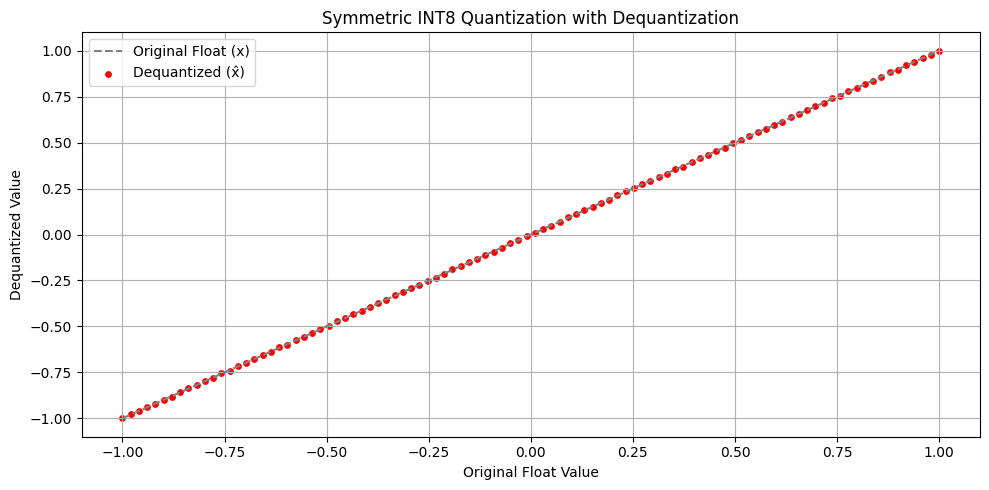

In [5]:
# ============================    8-BIT SYMMETRIC QUANTIZATION     ================================
#  Convert 32-bit floating point model weights into 8-bit integers (INT8) to reduce memory by ~4x
# =================================================================================================

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-1.0, 1.0, 100)   # Simulate 100 weights uniformly spread from -1 to 1
print("First ten original float values (model weights): ", x[:10])

# Define Quantization parameters by mapping our float range [-1.0, 1.0] into the INT8 range [-128, 127]
min_x  = -1.0   # minimum float value in our weight tensor
max_x  =  1.0   # maximum float value in our weight tensor
qmin   = -128   # minimum INT8 value
qmax   =  127   # maximum INT8 value

# Scale Factor Formula
absmax = np.max(np.abs(x))              # absolute maximum of the weight tensor
scale  = absmax / qmax                  # symmetric scale formula
print(f"\nScale = {scale:.6f}")

# Zero Point Z = 0 always for symmetric quantization. float 0.0 maps exactly to integer 0 — no shift needed
zero_point = 0
print(f"\nZero_point = {zero_point}")

# Quantization: Float32 → INT8
q = np.round(x / scale).astype(int)    # symmetric: no zero point in round step
q = np.clip(q, qmin, qmax)
print("\nFirst ten Quantized values: ", q[:10])

# Dequantization — INT8 → Float32
x_hat = scale * q                       # symmetric: no zero point in dequant step
print("\nFirst ten Dequantized Values: ", x_hat[:10])

# Quantization Error = difference between original (x) and reconstructed (x_hat)
# Max error is at most scale/2 ≈ 0.00394 (half a step size)
error = np.abs(x - x_hat)
print("\nQuantization Error:")
print(f"  Max error  : {error.max():.6f}")
print(f"  Mean error : {error.mean():.6f}")

# Plot original vs. dequantized
plt.figure(figsize=(10, 5))
plt.plot(x, x, label='Original Float (x)', linestyle='--', color='gray')
plt.scatter(x, x_hat, label='Dequantized (x̂)', color='red', s=15)
plt.title('Symmetric INT8 Quantization with Dequantization')
plt.xlabel('Original Float Value')
plt.ylabel('Dequantized Value')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# <span style='background :lightgreen' >5. INT4 Symmetric and Asymmetric Quantization</span>
<img align="right" width="500"  src="../images/quant02.png"  >

- **4-bit Quantization (INT4)** converts 32-bit floating point weights into 4-bit signed integers, reducing memory by **8×** (from 4 bytes to just 0.5 bytes per parameter) — twice the compression of INT8 but at the cost of significantly higher quantization error.
- It comes in two variants — **symmetric** and **asymmetric** — which differ in how they map the float range to the integer range.
- **The core idea is the same as INT8 but with far fewer buckets:** the continuous range of float values is divided into only **16 equally spaced discrete buckets** (bins) — compared to 256 buckets in INT8, this is a dramatic reduction in precision that makes every step ~17× coarser. The slight asymmetry (-8 to +7 instead of -8 to +8) is an inherent property of signed binary representation — there is always one extra negative value
- **Memory Impact** is dramatic — for a 7B parameter model:
  - `float32` : 7B × 4.0 bytes = **28.0 GB**
  - `INT8`    : 7B × 1.0 byte  =  **7.0 GB** (75% saving)
  - `INT4`    : 7B × 0.5 bytes =  **3.5 GB** (87.5% saving)
- **When to use INT4:** Best suited for **memory-constrained inference** on consumer hardware (laptops, free-tier GPUs) where even INT8 does not fit. Due to its coarse precision, raw INT4 is rarely used alone in practice — it is almost always paired with  **NF4 (QLoRA)**, which redistributes the 16 levels non-uniformly to far better match the normal distribution of real model weights, recovering much of the lost precision
  
## a. Symmetric INT4 Quantization

- **"Symmetric"** means float `0.0` always maps to integer `0` and the float range is
  mirrored equally around zero. The zero point is always `Z = 0`. The **16 levels** are
  equally spaced with the same gap between every two consecutive levels:
```
  -1.0  -0.87  -0.73  ...  0.0  ...  +0.73  +0.87  +1.0
    ↓     ↓      ↓           ↓          ↓      ↓      ↓
   -8    -7     -6    ...    0   ...    +6     +7    (+8 does not exist)
```

- **The Scale Factor** is anchored to the positive side only, since the range is mirrored
  around zero and `Z = 0` is enforced:
  - `scale = absmax / qmax`
  - Example: for float range `[-1.0, +1.0]` → `absmax = 1.0`, `qmax = 7`
  - `scale = 1.0 / 7 ≈ 0.14286`
  - Each integer step covers ~0.14286 in float space — compared to ~0.00787 in INT8
  - INT4 steps are therefore **~18× coarser** than INT8, leading to ~18× more quantization
    error
  - Note: the asymmetric formula `(float_max - float_min) / (int_max - int_min)` = `2.0 / 15 ≈ 0.13333`
    gives a different result and belongs to **asymmetric quantization** where zero point
    `Z ≠ 0` — it should not be used for symmetric quantization

- **Quantization (Float → INT4)** maps each float weight to its nearest integer bucket
  using a two-step formula:
  - **Step 1 — Round:** `q = round( x / scale )`
      - Since `Z = 0` for symmetric quantization, the full formula `round(x / scale + Z)`
        simplifies to `round(x / scale)` — the zero point term vanishes
      - Example: `x = 0.5` → `q = round(0.5 / 0.14286) = round(3.50) = 4`
      - The `round()` operation is what causes quantization error — any float value that
        falls between two integer steps gets snapped to the nearest step, losing the
        fractional part permanently. The much larger step size means rounding error is
        significantly larger than INT8
  - **Step 2 — Clip:** `q = clip(q, -8, +7)`
      - Clipping is a safeguard that forces any value outside the valid INT4 range back
        to the nearest boundary. Without clipping, an out-of-range integer like `-9` or
        `+8` would cause an overflow error since 4-bit storage physically cannot represent
        them
      - Any value below `-8` is clamped to `-8`; any value above `+7` is clamped to `+7`

- **Dequantization (INT4 → Float)** converts stored integers back to approximate float
  values for inference. Since `Z = 0` the full formula simplifies to:
  - Full formula: `x_hat = scale × (q - Z)`
  - Simplified:   `x_hat = scale × q`
  - Example: `x_hat = 0.14286 × 4 = 0.57143`  (original was `0.5` → error = `0.07143`)
  - Compare to INT8: the same weight `0.5` dequantizes to `0.50368` → error of only `0.00368`
  - The coarser approximation produces a visible **staircase effect** when plotting
    dequantized values against the original float values
- **Best for:** weight tensors which are naturally centered around zero — used in BnB
  INT4, NF4, and QLoRA

## b. Asymmetric INT4 Quantization
- **"Asymmetric"** means the float range is **not assumed to be centered at zero** — it
  can be entirely positive, entirely negative, or skewed to one side. A **non-zero zero
  point `Z`** is introduced that shifts the integer range to align with the actual float
  range:
```
  0.0  ...  +3.2  ...  +6.4  ...  +9.6             ← skewed float range (e.g. ReLU output)
   ↓           ↓          ↓          ↓
  -8    ...   -3   ...   +3   ...   +7              ← integer range shifted via Z
```

- **The Scale Factor** spans the full float range divided by the full integer range:
  - `scale = (float_max - float_min) / (int_max - int_min)`
  - Example: for float range `[0.0, +9.6]` → `float_max = 9.6`, `float_min = 0.0`
  - `scale = (9.6 - 0.0) / (7 - (-8)) = 9.6 / 15 ≈ 0.64`
  - Each integer step covers ~0.64 in float space
- **The Zero Point `Z`** shifts the integer grid so that `float_min` maps exactly to
  `int_min`. It is computed as:
  - `Z = round(int_min - float_min / scale)`
  - `Z = round(-8 - (0.0 / 0.64))`
  - `Z = round(-8 - 0)`
  - `Z = -8`
  - `Z = clip(Z, -8, +7) = -8`
  - This means integer `-8` corresponds to float `0.0` in this example
- **Quantization (Float → INT4)** includes the zero point in the rounding step:
  - **Step 1 — Round:** `q = round( x / scale + Z )`
      - The `+ Z` term shifts the integer grid to align with the skewed float range
      - Example: `x = 4.8` → `q = round(4.8 / 0.64 + (-8))`
                             `= round(7.5 - 8)`
                             `= round(-0.5)`
                             `= 0`
      - The `round()` operation is what causes quantization error — any float value that
        falls between two integer steps gets snapped to the nearest step, losing the
        fractional part permanently
  - **Step 2 — Clip:** `q = clip(q, -8, +7)`
      - Same safeguard as symmetric — forces any out-of-range value back to the nearest
        valid INT4 boundary
- **Dequantization (INT4 → Float)** must subtract the zero point to recover the float
  value correctly:
  - Full formula: `x_hat = scale × (q - Z)`
  - Example: `x_hat = 0.64 × (0 - (-8))`
                    `= 0.64 × 8`
                    `= 5.12`  (original was `4.8` → error = `0.32`)
  - The zero point `Z` cannot be dropped here — omitting it would shift all dequantized values by a constant offset, producing completely wrong results
- **Best for:** activation tensors after ReLU or other non-linearities that produce skewed, non-zero-centered distributions
- **Quantization Error** is significantly higher than INT8 — the maximum possible error is **half a step size**.

First ten original float values (model weights):  [-1.         -0.97979798 -0.95959596 -0.93939394 -0.91919192 -0.8989899
 -0.87878788 -0.85858586 -0.83838384 -0.81818182]

Scale = 0.142857

Zero_point = 0

First ten Quantized values:  [-7 -7 -7 -7 -6 -6 -6 -6 -6 -6]

First ten Dequantized Values:  [-1.         -1.         -1.         -1.         -0.85714286 -0.85714286
 -0.85714286 -0.85714286 -0.85714286 -0.85714286]

Quantization Error:
  Max error  : 0.070707
  Mean error : 0.035354


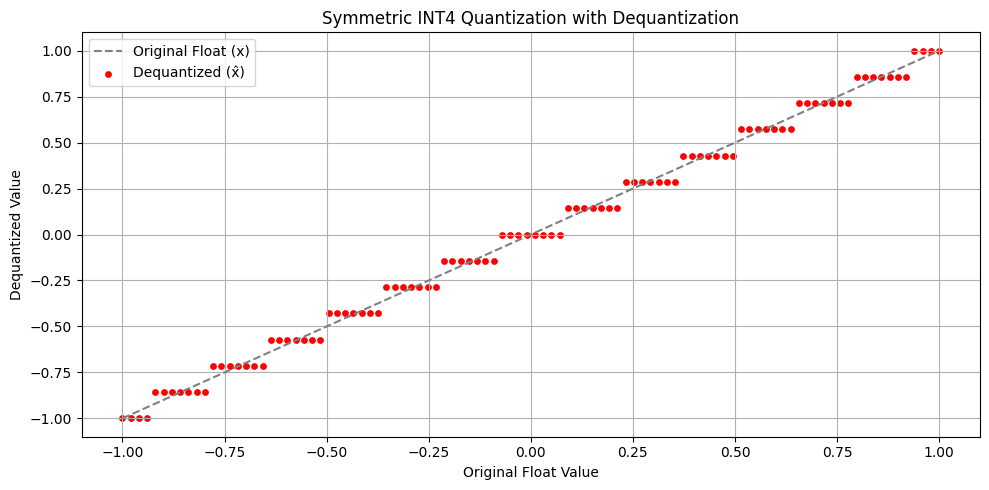

In [6]:
# ============================    4-BIT SYMMETRIC QUANTIZATION     ================================
#  Convert 32-bit floating point model weights into 4-bit integers (INT4) to reduce memory by ~8x
# =================================================================================================
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-1.0, 1.0, 100)   # Simulate 100 weights uniformly spread from -1 to 1
print("First ten original float values (model weights): ", x[:10])

# Define Quantization parameters by mapping our float range [-1.0, 1.0] into the INT4 range [-8, 7]
min_x = -1.0   # minimum float value in our weight tensor
max_x =  1.0   # maximum float value in our weight tensor
qmin  =  -8    # minimum INT4 value  (2^(4-1) = 8)
qmax  =   7    # maximum INT4 value  (2^(4-1) - 1 = 7)

# Scale Factor Formula
absmax = np.max(np.abs(x))              # absolute maximum of the weight tensor
scale  = absmax / qmax                  # symmetric scale formula
print(f"\nScale = {scale:.6f}")

# Zero Point Z = 0 always for symmetric quantization. float 0.0 maps exactly to integer 0 — no shift needed
zero_point = 0
print(f"\nZero_point = {zero_point}")

# Quantization: Float32 → INT4
q = np.round(x / scale).astype(int)    # symmetric: no zero point in round step
q = np.clip(q, qmin, qmax)
print("\nFirst ten Quantized values: ", q[:10])

# Dequantization — INT4 → Float32
x_hat = scale * q                       # symmetric: no zero point in dequant step
print("\nFirst ten Dequantized Values: ", x_hat[:10])

# Quantization Error = difference between original and reconstructed
# Max error is at most scale/2 ≈ 0.07143 (half a step size)
error = np.abs(x - x_hat)
print("\nQuantization Error:")
print(f"  Max error  : {error.max():.6f}")
print(f"  Mean error : {error.mean():.6f}")

# Plot original vs. dequantized
plt.figure(figsize=(10, 5))
plt.plot(x, x, label='Original Float (x)', linestyle='--', color='gray')
plt.scatter(x, x_hat, label='Dequantized (x̂)', color='red', s=15)
plt.title('Symmetric INT4 Quantization with Dequantization')   # ← CHANGED title
plt.xlabel('Original Float Value')
plt.ylabel('Dequantized Value')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# <span style='background :lightgreen' >6. Example Questions (INT8 and INT4 Quantization)</span>

### **Question 1**
- A language model has **3 billion parameters**.
    - **(a)** How much memory does it require in float32?
    - **(b)** How much memory does it require in float16?
    - **(c)** How much memory does it require after INT8 quantization?
    - **(d)** How much memory does it require after INT4 quantization?
    - **(e)** How much extra memory does INT8 use compared to INT4?
    - **(f)** What is the compression ratio from fp32 to INT4?

<details>
<summary>💡 <b>Click to reveal answer</b></summary>
<ul> (a) float32 memory   = 3B × 4.0 bytes    = 12.0 GB</ul>
<ul> (b) float16 memory   = 3B × 2.0 bytes    = 6.0 GB</ul>
<ul> (c) INT8 memory      = 3B × 1.0 byte     = 3.0 GB</ul>
<ul> (d) INT4 memory      = 3B × 0.5 bytes    = 1.5 GB</ul>
<ul> (e) Extra memory     = 3.0 - 1.5         = 1.5 GB more for INT8 vs INT4</ul>
<ul> (f) Compression ratio= 4 bytes / 0.5 byte= 8x compression</ul>
</details>

### **Question 2 (Symmetric INT8)**
- You have a **weight tensor** with values ranging from **-2.0 to +2.0**.
- This tensor is centered around zero, making it ideal for **symmetric quantization**.
- You want to quantize it to **INT8 symmetric quantization** (range: -128 to 127).
    - **(a)** Calculate the scale factor
    - **(b)** Quantize the weight `x = 1.5` to INT8
    - **(c)** Dequantize the result back to float
    - **(d)** What is the quantization error?

<details>
<summary>💡 <b>Click to reveal answer</b></summary>

```
Given:
  float range = [-2.0, +2.0]   ← perfectly centered around zero
  INT8 range  = [-128, +127]
  zero point  = 0               ← always 0 for symmetric quantization
  x           = 1.5

(a) scale = absmax / qmax = 2.0 / 127 ≈ 0.015748 per step 

(b) q = round(x / scale + Z) = round(1.5 / 0.015748 + 0) = round(95.25) = 95   ← stored as INT8
    clip(95, -128, 127) = 95   ← within valid INT8 range, no clipping needed

(c) x_hat = scale × (q - Z) = 0.015748 × (95 - 0) ≈ 1.4961

(d) error = |x - x_hat| = |1.5 - 1.4961| ≈ 0.0039   ← less than half a step size (0.015748 / 2 ≈ 0.007874)
                        very small error — symmetric works well here because
                        the float range is perfectly centered around zero
```
</details>



### **Question 3 (Asymmetric INT8)**
- You have an **activation tensor** after a ReLU layer with values ranging from
  **0.0 to +4.0**.
- This tensor is entirely positive and skewed, making it ideal for **asymmetric quantization**.
- You want to quantize it to **INT8 asymmetric quantization** (range: -128 to 127).
    - **(a)** Calculate the scale factor
    - **(b)** Calculate the zero point `Z`
    - **(c)** Quantize the activation `x = 3.0` to INT8
    - **(d)** Dequantize the result back to float
    - **(e)** What is the quantization error?
    - **(f)** Why would symmetric quantization perform poorly on this tensor?

<details>
<summary>💡 <b>Click to reveal answer</b></summary>

```
Given:
  float range = [0.0, +4.0]    ← entirely positive, skewed distribution
  INT8 range  = [-128, +127]
  x           = 3.0

(a) scale = (float_max - float_min) / (int_max - int_min)
          = (4.0 - 0.0) / (127 - (-128)) = 4.0 / 255 ≈ 0.015686 per step

(b) Z = round(int_min - float_min / scale) = round(-128 - (0.0 / 0.015686)) = round(-128) = -128   ← float 0.0 maps to integer -128
                 (this is the key difference from symmetric quantization)
    clip(-128, -128, 127) = -128   ← within valid INT8 range

(c) q = round(x / scale + Z) = round(3.0 / 0.015686 + (-128)) = round(191.25 - 128) = round(63.25) = 63   ← stored as INT8
    clip(63, -128, 127) = 63   ← within valid INT8 range, no clipping needed

(d) x_hat = scale × (q - Z) = 0.015686 × (63 - (-128)) = 0.015686 × 191 ≈ 2.9961

(e) error = |x - x_hat| = |3.0 - 2.9961| ≈ 0.0039   ← less than half a step size (0.015686 / 2 ≈ 0.007843)

(f) Why symmetric would fail here:
    scale_symmetric = absmax / qmax = 4.0 / 127 ≈ 0.031496
                This mirrors the range to [-4.0, +4.0] in float space even though
                NO weights exist in [-4.0, 0.0]. This wastes the entire negative half
                of the integer range [-128, 0] on float values that never appear:
    Symmetric:   integer range [-128,   0] → float [-4.0,  0.0]  ← wasted
                 integer range [   0, 127] → float [ 0.0, +4.0]  ← used
    Asymmetric:  integer range [-128, 127] → float [ 0.0, +4.0]  ← fully used
    Result: symmetric step size (0.031496) is 2× coarser than asymmetric
    (0.015686), meaning symmetric quantization wastes half its precision
    on a float region that contains no actual data — asymmetric quantization
    utilizes all 255 levels efficiently by shifting Z = -128
```
</details>

### **Question 4 (Symmetric INT4)**
- You have a **weight tensor** with values ranging from **-1.0 to +1.0**.
- This tensor is centered around zero, making it ideal for **symmetric quantization**.
- You want to quantize it to **INT4 symmetric quantization** (range: -8 to +7, i.e., 16 levels).
    - **(a)** Calculate the scale factor
    - **(b)** Quantize the weight `x = 0.6` to INT4
    - **(c)** Dequantize the result back to float
    - **(d)** What is the quantization error?
    - **(e)** Compare this error to INT8 symmetric — what does it tell you?

<details>
<summary>💡 <b>Click to reveal answer</b></summary>

```
Given:
  float range = [-1.0, +1.0]   ← perfectly centered around zero
  INT4 range  = [-8, +7]  (16 levels)
  zero point  = 0               ← always 0 for symmetric quantization
  x           = 0.6

(a) scale = absmax / qmax  = 1.0 / 7   ≈ 0.142857 per step

(b) q = round(x / scale + Z) = round(0.6 / 0.142857 + 0) = round(4.200) = 4   ← stored as 4-bit integer
    clip(4, -8, 7) = 4   ← within valid INT4 range, no clipping needed

(c) x_hat = scale × (q - Z) = 0.142857 × (4 - 0) ≈ 0.571429

(d) error = |x - x_hat|   = |0.6 - 0.571429|   ≈ 0.028571

(e) INT8 symmetric scale = absmax / qmax = 1.0 / 127 ≈ 0.007874
    INT4 symmetric scale = absmax / qmax = 1.0 / 7   ≈ 0.142857

    max error INT8 = 0.007874 / 2 ≈ 0.003937
    max error INT4 = 0.142857 / 2 ≈ 0.071429

    Ratio: 0.071429 / 0.003937 ≈ 18×
    INT4 max error is ~18× LARGER than INT8
    Fewer levels (16 vs 256) = coarser step size = much higher error
    This is the fundamental trade-off — INT4 saves 2× memory vs INT8
    but at the cost of ~18× more quantization error
```
</details>



### **Question 5 (Asymmetric INT4)**
- You have an **activation tensor** after a ReLU layer with values ranging from
  **0.0 to +3.0**.
- This tensor is entirely positive and skewed, making it ideal for **asymmetric quantization**.
- You want to quantize it to **INT4 asymmetric quantization** (range: -8 to +7, i.e., 16 levels).
    - **(a)** Calculate the scale factor
    - **(b)** Calculate the zero point `Z`
    - **(c)** Quantize the activation `x = 2.0` to INT4
    - **(d)** Dequantize the result back to float
    - **(e)** What is the quantization error?
    - **(f)** Why would symmetric quantization perform poorly on this tensor?

<details>
<summary>💡 <b>Click to reveal answer</b></summary>

```
Given:
  float range = [0.0, +3.0]    ← entirely positive, skewed distribution
  INT4 range  = [-8, +7]  (16 levels)
  x           = 2.0

(a) scale = (float_max - float_min) / (int_max - int_min)
          = (3.0 - 0.0) / (7 - (-8)) = 3.0 / 15 = 0.200000 per step  

(b) Z = round(int_min - float_min / scale) = round(-8 - (0.0 / 0.200000)) = round(-8) = -8   
    clip(-8, -8, 7) = -8   ← within valid INT4 range

(c) q = round(x / scale + Z)  = round(2.0 / 0.200000 + (-8)) = round(10.0 - 8) = round(2.0) = 2   ← stored as 4-bit integer
    clip(2, -8, 7) = 2   ← within valid INT4 range, no clipping needed

(d) x_hat = scale × (q - Z)  = 0.200000 × (2 - (-8))  = 0.200000 × 10  = 2.000000

(e) error = |x - x_hat|  = |2.0 - 2.0| = 0.0000   ← perfect reconstruction in this case!

(f) Why symmetric would fail here:
    scale_symmetric = absmax / qmax = 3.0 / 7  ≈ 0.428571

    This mirrors the range to [-3.0, +3.0] in float space even though
    NO activations exist in [-3.0, 0.0]. This wastes the entire negative
    half of the integer range [-8, 0] on float values that never appear:

    Symmetric:   integer range [-8,  0] → float [-3.0,  0.0]  ← wasted
                 integer range [ 0, +7] → float [ 0.0, +3.0]  ← used
    Asymmetric:  integer range [-8, +7] → float [ 0.0, +3.0]  ← fully used

    Result: symmetric step size (0.428571) is ~2× coarser than asymmetric
    (0.200000), meaning symmetric quantization wastes half its 16 levels
    on a float region that contains no actual data.

    With only 16 levels total in INT4 (vs 256 in INT8), wasting 8 of them
    is far more damaging than in INT8 — every wasted level matters much
    more when precision is already extremely limited
```
</details>

### **Question 6 (Normal Distribution Problem)**
- You have a weight tensor of **100 weights** that are **normally distributed** with
  mean = 0 and standard deviation = 0.5. For simplicity, assume the weights are
  spread as follows:
  - **68 weights** fall in the range **[-0.5, +0.5]**  (within 1 standard deviation)
  - **27 weights** fall in the range **[-1.0, -0.5) and (+0.5, +1.0]**  (within 2 standard deviations)
  - **5 weights** fall in the range **[-2.0, -1.0) and (+1.0, +2.0]**  (within 3 standard deviations)
  - The **absmax = 2.0** (the single largest weight at the extreme tail)
- You need to apply **INT4 symmetric quantization** (16 levels, range -8 to +7).
    - **(a)** Calculate the scale factor for this tensor
    - **(b)** Calculate the float range that each of the 16 INT4 buckets covers
    - **(c)** How many of the 100 weights fall into the central buckets (buckets -1, 0, +1) versus the extreme buckets (buckets -8, -7, -6, +5, +6, +7)?
    - **(d)** Quantize `x = 0.05` and `x = 0.14` — do they map to different buckets?
    - **(e)** What is normal distribution problem and why NF4 was invented?

<details>
<summary>💡 <b>Click to reveal answer</b></summary>

```
Given:
  100 weights, normally distributed, mean = 0, std = 0.5
  68 weights in [-0.5, +0.5]    ← 1 std dev — most weights live here
  27 weights in [-1.0, +1.0]    ← 2 std dev
   5 weights in [-2.0, +2.0]    ← 3 std dev — very few weights here
  absmax = 2.0
  INT4: qmin = -8, qmax = +7, 16 levels
  zero point Z = 0  ← symmetric quantization

(a) scale = absmax / qmax = 2.0 / 7 ≈ 0.285714 per step   ← each INT4 bucket covers 0.285714 in float space

(b) Float range covered by each INT4 bucket:
    Each bucket covers exactly one step = 0.285714 in float space.
    The 16 buckets and their float ranges are:

    Bucket  │  Float Range          │  Description
    ────────┼───────────────────────┼──────────────────────────────
      -8    │  [-2.2857, -2.0000]   │  extreme negative tail
      -7    │  [-2.0000, -1.7143]   │  far negative
      -6    │  [-1.7143, -1.4286]   │  far negative
      -5    │  [-1.4286, -1.1429]   │  far negative
      -4    │  [-1.1429, -0.8571]   │  moderate negative
      -3    │  [-0.8571, -0.5714]   │  moderate negative
      -2    │  [-0.5714, -0.2857]   │  near zero negative
      -1    │  [-0.2857,  0.0000]   │  near zero negative
       0    │  [ 0.0000, +0.2857]   │  near zero positive  ← most weights!
      +1    │  [+0.2857, +0.5714]   │  near zero positive  ← most weights!
      +2    │  [+0.5714, +0.8571]   │  moderate positive
      +3    │  [+0.8571, +1.1429]   │  moderate positive
      +4    │  [+1.1429, +1.4286]   │  far positive
      +5    │  [+1.4286, +1.7143]   │  far positive
      +6    │  [+1.7143, +2.0000]   │  far positive
      +7    │  [+2.0000, +2.2857]   │  extreme positive tail
    ────────┴───────────────────────┴──────────────────────────────

(c) Weight distribution across buckets:

    CENTRAL buckets (-1, 0, +1) cover float range [-0.2857, +0.5714]:
    → This range contains most of the 68 weights in [-0.5, +0.5]
    → Approximately 68 weights × (0.8571/1.0) ≈ 58 weights
    → ~58 out of 100 weights (58%) are squeezed into just 3 buckets!
    → These 58 weights are all INDISTINGUISHABLE within their bucket
      — they all dequantize to the same single float value

    EXTREME buckets (-8,-7,-6 and +5,+6,+7) cover float range beyond ±1.4286:
    → Only the 5 weights in [-2.0, -1.4286) and (+1.4286, +2.0] fall here
    → ~5 out of 100 weights (5%) spread across 6 extreme buckets
    → These 6 extreme buckets are almost ENTIRELY EMPTY!

    Summary:
    ┌─────────────────────────────────────────────────────────┐
    │  3 central buckets  → ~58 weights  (58%) — overcrowded  │
    │  7 middle buckets   → ~37 weights  (37%) — reasonable   │
    │  6 extreme buckets  →   ~5 weights  (5%) — nearly empty │
    └─────────────────────────────────────────────────────────┘
    This is the core problem — uniform bucket spacing is completely
    mismatched to the normal distribution of real LLM weights!

(d) Quantize x = 0.05 and x = 0.14:

    x = 0.05:
    q = round(0.05 / 0.285714) = round(0.175) = 0   ← maps to bucket 0

    x = 0.14:
    q = round(0.14 / 0.285714)  = round(0.49) = 0   ← maps to bucket 0

    So x = 0.05, and x = 0.14 both map to bucket 0
    and both dequantize to 0.0 — completely indistinguishable!
    These are weights with meaningful differences (0.05 vs 0.14
    is a 180% difference) yet INT4 treats them as identical.


(e) The Normal Distribution Problem:
    → Uniform buckets assume weights are EQUALLY LIKELY everywhere
    → But normal distribution means weights cluster near zero
    → Result: central buckets are OVERCROWDED (many weights share one bucket and become indistinguishable)
    → Extreme buckets are WASTED (almost no weights land there)
    → This is 16× worse in INT4 than INT8 because every wasted bucket costs far more when you only have 16 total

    Why NF4 was invented: NF4 bucket spacing is non-uniform:
    ┌───────────────────────────────────────────────────────┐
    │ Near zero:    tiny buckets  ← dense where weights are │
    │ At extremes:  huge buckets  ← sparse where few weights│
    └───────────────────────────────────────────────────────┘

    NF4 places more buckets near zero where 68% of weights live and fewer buckets at the extremes where only 5% of weights live.
    This means:
    → Weights near zero (the majority) are distinguished precisely
    → Extreme weights (the minority) are approximated coarsely
    → All 16 levels are used EFFICIENTLY — none are wasted
    → This recovers much of the precision lost by going from INT8 to INT4, which is exactly why QLoRA uses NF4 and not INT4
```
</details>

### **Question 7 (Outlier Problem in Symmetric Quantization)**
- You have a weight tensor of 128 weights. 127 of them are uniformly distributed between
  **-0.2 and +0.2**, and one outlier weight is **+9.6**.
- You need to apply **INT4 symmetric quantization** (16 levels, range -8 to +7).
    - **(a)** What is the absmax of this tensor?
    - **(b)** Calculate the scale factor for the ENTIRE tensor
    - **(c)** Quantize the weight `x = 0.15` using this scale factor. What integer does
      it map to?
    - **(d)** Dequantize the result. What is the error?
    - **(e)** Now imagine the outlier did NOT exist and absmax = 0.2. Recalculate the
      scale factor and repeat (c) and (d) for `x = 0.15`
    - **(f)** Compare the two errors. What does this tell you about the outlier problem?

<details>
<summary>💡 <b>Click to reveal answer</b></summary>

```
Given:
  128 weights, 127 in [-0.2, +0.2], 1 outlier = +9.6
  INT4: qmin = -8, qmax = +7, 16 levels
  zero point Z = 0  ← symmetric quantization, Z always = 0

(a) absmax = 9.6   ← the single outlier dominates the entire tensor

(b) scale = absmax / qmax = 9.6 / 7  ≈ 1.371429 per step   ← enormous step size caused entirely by the single outlier!

(c) q = round(x / scale + Z) = round(0.15 / 1.371429 + 0) = round(0.10938) = 0   ← maps to integer 0
    clip(0, -8, 7) = 0   ← within valid INT4 range

(d) x_hat = scale × (q - Z)   = 1.371429 × (0 - 0) = 0.0

    error = |0.15 - 0.0| = 0.15   ← 100% of the original value is lost!
                      
(e) Without outlier: absmax = 0.2
    scale = absmax / qmax   = 0.2 / 7   ≈ 0.028571 per step     ← much tighter step size!
    q = round(x / scale + Z) = round(0.15 / 0.028571 + 0) = round(5.250) = 5   ← stored as 4-bit integer
    clip(5, -8, 7) = 5   ← within valid INT4 range

    x_hat = scale × (q - Z) = 0.028571 × (5 - 0) ≈ 0.142857
    error = |0.15 - 0.142857| ≈ 0.007143

(f) Comparison:

    Scenario         Scale      q    x_hat    Error
    ─────────────────────────────────────────────────────────────
    With outlier     1.371429   0    0.0000   0.150000  (100% loss)
    Without outlier  0.028571   5    0.1429   0.007143  (4.8% loss)

    The ONE outlier (+9.6) increased the error by ~21× for a perfectly
    normal weight (0.15) that itself had nothing unusual about it!

    This is the outlier problem in its purest form:
    → The outlier forces absmax = 9.6 instead of 0.2
    → This makes the scale ~48× larger (1.371429 vs 0.028571)
    → A step size of 1.371429 is so coarse that any weight smaller than half a step (< 0.6857) collapses to bucket 0
    → All 127 normal weights in [-0.2, +0.2] are completely indistinguishable from each other — they ALL map to bucket 0!
    → Only the outlier itself is accurately represented

    This is significantly worse in INT4 than INT8 because:
    → INT4 has only 16 levels vs 256 in INT8
    → Each wasted level costs far more precision
    → With INT8 and the same outlier, scale = 9.6/127 ≈ 0.0756 meaning weights as small as 0.038 could still be distinguished
    → With INT4, weights must exceed 0.6857 to escape bucket 0 — none of the 127 normal weights qualify!

    → This is exactly why blockwise quantization was introduced:
      by quantizing small blocks of weights (e.g. 64) independently,
      an outlier in one block only destroys precision within that block
      rather than corrupting the entire tensor
```
</details>

# <span style='background :lightgreen' >7. [A Deep Dive into the Working of QLoRA - Quantized Low-Rank Adaptation](https://arxiv.org/abs/2305.14314)</span>
## The Three Innovations Introduced by QLoRA
- We have already seen that in order to Fine-Tune a 7B model using LoRA alone, we have reduced the GPU memory usage from 112 GB → ~14.5 GB (87% reduction), but still too tight for a free Colab T4 GPU (15 GB VRAM).
- Think of Fine-Tune a LLAMA 65B model using LoRA alone, requiring around 750 GB of GPU memory, i.e., sixteen A-40 GPUs.
- QLoRA helps us in this regard using three innovations:
```
╔══════════════════════════════════════════════════════════════════╗
║         QLoRA = 3 Innovations (Dettmers et al., 2023)            ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. NF4 Quantization    → Compress base model weights to 4-bit   ║
║                           using equally POPULATED bins that      ║
║                           exploit the normal distribution of LLM ║
║                           weights with minimal quality loss      ║
║                           14 GB → 3.5 GB (75% saving)            ║
║                                                                  ║
║  2. Double Quantization → Quantize the NF4 quantization          ║
║                           constants themselves (compress the     ║
║                           compression metadata)                  ║
║                           ~0.37 bits/param (~3.6 GB on 65B)      ║
║                                                                  ║
║  3. Paged Optimizers    → Page optimizer states (momentum +      ║
║                           variance) between GPU VRAM and CPU RAM ║
║                           when GPU fills up thus preventing OOM  ║
║                           crashes                                ║
║                                                                  ║
║  4. LoRA Adapters       → Freeze ALL base model weights and      ║
║                           train only small low-rank matrices     ║
║                           A and B → trains only ~1% of params    ║
║                           112 GB  → ~14.5 GB (87% saving)        ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  ⚡ Combined Effect (7B model):                                   ║
║   Full Fine-Tuning  →  112 GB     (8× A100s required)            ║
║   LoRA only         →   14.5 GB   (just barely fits T4)          ║
║   QLoRA (all 4)     →   ~4 GB     (fits FREE Colab T4)           ║
╚══════════════════════════════════════════════════════════════════╝
```



# <span style='background :lightgreen' >8. NF4 — Normal Float 4-bit Quantization</span>
<img align="right" width="500"  src="../images/quant03.png"  >

- **Normal Float 4-bit (NF4)** was introduced in the **QLoRA paper (2023)** and converts
  32-bit floating point weights into 4-bit representations, achieving the same **8× memory
  reduction** as INT4 but with significantly lower quantization error by exploiting the
  statistical distribution of LLM weights

## a. The Problem: Why INT4 Fails for LLM Weights
- INT4 places its 16 levels at **equally spaced intervals** across [-1, 1] — this works
  fine only if weights are **uniformly distributed**
- But pretrained LLM weights are **not uniform** — they follow a **normal (bell-curve)
  distribution**, meaning most weights cluster near zero and very few exist at the extremes
- As a result, INT4 wastes most of its 16 buckets on extreme regions where almost no
  weights exist, while the central region — where the vast majority of weights live —
  is severely under-represented
```
INT4 (equally spaced):         NF4 (matched to normal distribution):

│    │    │    │    │          │  │  │ ││ ││ │ │  │  │
─────────────────────          ─────────────────────────
-1.0                1.0        -1.0                  1.0

INT4: 16 buckets spread        NF4: 16 buckets packed
      uniformly — most               tightly near zero
      weights crowd the              where most weights
      same few center buckets        actually live
```

- NF4 asks a fundamentally different question than INT4:
  - ❌ **INT4 asks:** *"How do I space 16 levels equally across the value range?"*
  - ✅ **NF4 asks:** *"How do I place 16 levels so each one captures the same number of weights?"*


## b. The Core Idea: Information-Theoretically Optimal Bucketing

- NF4 still uses 4 bits = **16 levels** and the **same memory as INT4**
- But the 16 levels are **not equally spaced** — they are placed where the weights
  actually are: **dense near zero, sparse at the extremes**
- Theoretically, each of the 16 NF4 buckets captures exactly `1/16 = 6.25%` of all weights
- This is called **"information-theoretically optimal"** quantization — every bit of the
  4-bit representation carries maximum useful information

## c. How NF4 Works?
#### (i) NF4 Levels
- The 16 NF4 levels are **fixed constants** pre-computed using the **Inverse Normal CDF (Quantile Function)** — they do not change per tensor:
  - Divide the probability range [0, 1] into 16 equally spaced segments
  - Apply the inverse of the Normal CDF (`scipy.stats.norm.ppf`) to each boundary
  - Take the midpoint of each segment as the quantization level
  - Normalize all levels to the range [-1, 1]
  - **Result:** levels are densely packed near zero (fine precision where most weights
    are) and sparse at the extremes (coarser precision where very few weights exist)
```python
NF4_LEVELS = [
    -1.0,  -0.6962, -0.5251, -0.3949, -0.2844, -0.1848, -0.0911,  0.0,
     0.0796,  0.1609,  0.2461,  0.3379,  0.4407,  0.5626,  0.7230,  1.0
]
```
#### (ii) Scale Factor in NF4
- Unlike INT4/INT8 which compute a linear step size, NF4 uses the **absolute maximum (absmax)** of the weight tensor to normalize the entire tensor to [-1, 1] before quantization:
  - `scale = max(|x|)`

#### (iii) Quantization (Float → NF4 Index)
- NF4 quantization is a **lookup table approach**, and for each weight find the closest NF4 level (No clipping required):
    - `distances = |x_normalized - nf4_levels| = |x / scale - nf4_levels|`
    - `q = argmin(distances)`  → store the index (0–15) of the nearest level
- Example: `x = 0.5` with a scale of 1.0 
    - `distances = |0.5/1.0 - nf4_levels| → nearest NF4 level is `0.5626` at index `13` → store `13` 
#### (iv) Dequantization (NF4 Index → Float)
- Dequantization simply reverses the lookup and rescales:
  - `x_hat = nf4_levels[q] × scale`
- Example: `x_hat = nf4_levels[13] × scale = 0.5626 × 1.0 = 0.5626`  (original was `0.5` → error = `0.0626`)

#### (v) Quantization Error
- The maximum possible error is **not uniform** across the range — unlike INT4 where every region has the same step size, NF4 error varies by region:
  - **Near zero:** very small error (levels are densely packed)
  - **Near ±1:** larger error (levels are sparse, fewer weights live here anyway)
- Using the same 4 bits and 16 levels:
  - `INT4` mean error ≈ `0.0422`  (uniform error across all weights)
  - `NF4`  mean error ≈ `0.0163`  (lower error near zero, where most weights are)
  - NF4 achieves **~2.6× lower mean error** than INT4 with **identical memory usage**

### **Question 8 (Simple NF4)**
- You have a small weight tensor of 16 weights drawn from a pretrained transformer layer:
```
weights = [-0.9, -0.6, -0.5, -0.3, -0.2, -0.1, -0.05, 0.0,
            0.05,  0.1,  0.2,  0.3,  0.5,  0.6,  0.8,  0.9]
```
- The **16 fixed non-uniform NF4 levels** (pre-computed from normal distribution) are:
```python
NF4_LEVELS = [
  -1.0000, -0.6962, -0.5251, -0.3949, -0.2844,
  -0.1848, -0.0911,  0.0000,  0.0796,  0.1609,
   0.2461,  0.3379,  0.4407,  0.5626,  0.7230,  1.0000
]
Indices:
   0        1        2        3        4
   5        6        7        8        9
  10       11       12       13       14       15
```

- **(a)** What is the absmax scale factor for this tensor? Normalize all 16 weights to the range [-1, 1] using absmax. Show the normalized tensor.
- **(b)** Quantize the following 4 weights by finding the nearest NF4 level for each normalized value. Show the distance calculation for each and state which index (0–15) is stored:
    - `w = -0.9`
    - `w = -0.1`
    - `w =  0.3`
    - `w =  0.8`
- **(c)** Dequantize the 4 weights from part (b) back to float values. Calculate the quantization error for each. Which weight has the largest error and why?
- **(d)** Compare NF4 to INT4 for this tensor. INT4 uses 16 equally spaced levels from -1.0 to +1.0. Quantize `w = 0.05` using both NF4 and INT4. Which gives lower error and why?
- **(e)** How much memory does storing these 16 weights consume:
    - As float32?
    - As NF4?
    - What is the memory reduction?

<details>
<summary>💡 <b>Click to reveal answer</b></summary>

```
Given:
  16 weights ranging from -0.9 to +0.9
  NF4: 16 non-uniform levels (pre-computed from normal distribution)
  INT4: 16 uniform levels from -1.0 to +1.0

(a) Absmax scale factor:
    absmax = max(|-0.9|, |-0.6|, ..., |0.9|) = 0.9

    Normalized weights = weights / absmax = weights / 0.9:
    [-1.0000, -0.6667, -0.5556, -0.3333, -0.2222, -0.1111, -0.0556, 0.0000,
      0.0556,  0.1111,  0.2222,  0.3333,  0.5556,  0.6667,  0.8889, 1.0000]

    All values now lie within [-1, 1] 

(b) Quantization — find nearest NF4 level for each:

    NF4_LEVELS = [-1.0000, -0.6962, -0.5251, -0.3949, -0.2844,
                  -0.1848, -0.0911,  0.0000,  0.0796,  0.1609,
                   0.2461,  0.3379,  0.4407,  0.5626,  0.7230, 1.0000]

    w = -0.9 → normalized = -0.9/0.9 = -1.0000
      Distances to nearest few levels:
        index 0: |-1.0000 - (-1.0000)| = 0.0000  ← nearest ✅
        index 1: |-1.0000 - (-0.6962)| = 0.3038
      Stored index = 0

    w = -0.1 → normalized = -0.1/0.9 = -0.1111
      Distances to nearest few levels:
        index 5: |-0.1111 - (-0.1848)| = 0.0737
        index 6: |-0.1111 - (-0.0911)| = 0.0200  ← nearest ✅
        index 7: |-0.1111 - ( 0.0000)| = 0.1111
      Stored index = 6

    w = 0.3 → normalized = 0.3/0.9 = 0.3333
      Distances to nearest few levels:
        index 10: |0.3333 - 0.2461| = 0.0872
        index 11: |0.3333 - 0.3379| = 0.0046  ← nearest ✅
        index 12: |0.3333 - 0.4407| = 0.1074
      Stored index = 11

    w = 0.8 → normalized = 0.8/0.9 = 0.8889
      Distances to nearest few levels:
        index 14: |0.8889 - 0.7230| = 0.1659
        index 15: |0.8889 - 1.0000| = 0.1111  ← nearest ✅
      Stored index = 15

(c) Dequantization: x_hat = NF4_LEVELS[index] × scale

    w = -0.9  stored at index 0  with a NF4 level of -1.0000
        x_hat = nf4_levels[q] × scale = nf4_levels[0] × 0.9 = -1.0 × 0.9 = -0.9
        error = |-0.9 - (-0.9)| = 0.0000  ← perfect! 

    w = -0.1  stored at index 6  with a NF4 level of -0.0911
        x_hat = nf4_levels[q] × scale = nf4_levels[6] × 0.9 = -0.0911 × 0.9 = -0.0820
        error = |-0.1 - (-0.0820)| = 0.0180   ← small

    w = 0.3  stored at index 11  with a NF4 level of 0.3379
        x_hat = nf4_levels[q] × scale = nf4_levels[11] × 0.9 = 0.3379 × 0.9 = 0.3041
        error = |0.3 - 0.03041| = 0.0041   ← very small

    w = 0.8  stored at index 15  with a NF4 level of 1.0000
        x_hat = nf4_levels[q] × scale = nf4_levels[15] × 0.9 = 1.0000 × 0.9 = 0.9000
        error = |0.8 - 0.9000| = 0.1000   ← largest error

    w = 0.8 has the largest error because it is an extreme
    value near ±1 where NF4 levels are SPARSE — there is a
    large gap between index 14 (0.7230) and index 15 (1.0000).
    NF4 deliberately places fewer levels at the extremes
    because very few pretrained weights actually live there.
    The tradeoff is acceptable since extreme weights are rare.

(d) NF4 for w = 0.05:

    w = 0.05 → normalized = 0.05/0.9 = 0.0556
    Distances to nearest few levels:
        index 7: |0.0556 - 0.0000| = 0.0556
        index 8: |0.0556 - 0.0796| = 0.0240  ← nearest ✅
        index 9: |0.0556 - 0.1609| = 0.1053
        Stored index = 8 
    x_hat = nf4_levels[q] × scale = nf4_levels[8] × 0.9 = 0.0796 × 0.9 = 0.07164
    error = |0.05 - 0.0716| = 0.02164

INT4 for w = 0.05:
    scale = absmax / qmax  = 0.9 / 7   ≈ 0.12857 per step
    q = round(x / scale + Z) = round(0.05 / 0.12857 + 0) = round(0.3888) = 0   ← stored as 4-bit integer
    clip(0, -8, 7) = 0   ← within valid INT4 range, no clipping needed
    x_hat = scale × (q - Z) = 0.12857 × (0 - 0) ≈ 0.0
    error = |x - x_hat|   = |0.05 - 0.0|   ≈ 0.05

    NF4 gives lower error because its levels are DENSELY
    PACKED near zero — where this weight (0.05) actually lives.
    INT4's uniform spacing wastes resolution at extremes and
    under-serves the central region where most weights cluster.

(e) Memory comparison for 16 weights:

    float32: 16 × 4 bytes = 64 bytes
    NF4    : 16 × 0.5 bytes = 8 bytes
              (each weight stored as a 4-bit index, 0–15)
              (2 weights packed into every 1 byte)
    Memory reduction = (64 - 8) / 64 × 100 = 87.5%
    NF4 uses 8× less memory than float32 
```
</details>

# <span style='background :lightgreen' >9. The Outlier Problem in NF4 and its Solution (Blockwise NF4)</span>
## a. The Outlier Problem in NF4
- NF4 with a single scale factor suffers from outliers — if even one weight is very large, it dominates the `absmax` and forces all other weights to be normalized into a tiny region near zero, where they all collapse into the same few buckets:
```python
NF4_LEVELS = [
    -1.0,  -0.6962, -0.5251, -0.3949, -0.2844, -0.1848, -0.0911,  0.0,
     0.0796,  0.1609,  0.2461,  0.3379,  0.4407,  0.5626,  0.7230,  1.0
]
```
- Imagine a weight tensor with 1000 weights:
    - Most weights: small values between -0.1 and +0.1
    - One outlier:  +50.0  ← a single extreme value
    - Single scale factor:
        - scale = max(|x|) = 50.0
        - x_normalized for 0.05 → 0.05 / 50.0 = 0.001  → maps to NF4 level ≈ 0.0
        - x_normalized for 0.09 → 0.09 / 50.0 = 0.0018 → maps to NF4 level ≈ 0.0
- Both weights collapse into the same NF4 bucket → precision completely destroyed for 99.9% of weights because of ONE outlier
- The single outlier (+50.0) forces a larger scale factor, which squashes all small weights into the central NF4 buckets near zero — destroying their precision.

### **Question 9** (Simple NF4 and the Outlier Problem)
- You have a weight tensor of **8 weights** (small for easy calculation):
```
weights = [-0.18, -0.12, -0.05, 0.03, 0.08, 0.15, 0.19, 0.20]
```
- The 16 fixed NF4 levels are:
```python
NF4_LEVELS = [-1.0000, -0.6962, -0.5251, -0.3949, -0.2844,
              -0.1848, -0.0911,  0.0000,  0.0796,  0.1609,
               0.2461,  0.3379,  0.4407,  0.5626,  0.7230, 1.0000]
Indices:         0        1        2        3        4
                 5        6        7        8        9
                10       11       12       13       14       15
```
- **(a)** What is the absmax scale factor for this tensor?
          Normalize `x = 0.15` to the range [-1, 1].
- **(b)** Quantize the normalized value of `x = 0.15` by finding
          the nearest NF4 level. Show the distance to the two
          nearest levels. State which index is stored.
- **(c)** Dequantize the stored index back to a float value.
          Calculate the quantization error.
- **(d)** Now a new outlier weight **+9.6** is added to the tensor. Repeat (a), (b) and (c) and compare the two errors:
```
weights = [-0.18, -0.12, -0.05, 0.03, 0.08, 0.15, 0.19, 0.20, +9.6]
```
- **(e)** What does this tell us about the fundamental limitation
          of simple NF4 when outliers are present?
<details>
<summary>💡 <b>Click to reveal answer</b></summary>

```
Given:
  weights  = [-0.18, -0.12, -0.05, 0.03, 0.08, 0.15, 0.19, 0.20]
  NF4 uses absmax normalization: x_normalized = x / absmax
  Dequantization: x_hat = NF4_LEVELS[index] × absmax

(a) Scale factor WITHOUT outlier:
    absmax = max(|-0.18|, |-0.12|, |-0.05|, |0.03|, |0.08|,  |0.15|,  |0.19|, |0.20|)  = 0.20

(b) Quantization — find nearest NF4 level for 0.15:
    w = 0.15 → normalized = 0.15/0.20 = 0.7500
    Distances to nearest few levels:
    index 13: |0.7500 - 0.5626| = 0.1874  
    index 14: |0.7500 - 0.7230| = 0.0270  ← nearest ✅
    index 15: |0.7500 - 1.0000| = 0.2500
    Stored index = 14

(c) Dequantization: x_hat = NF4_LEVELS[index] × scale
    w = 0.15  stored at index 14  with a NF4 level of 0.7230
        x_hat = nf4_levels[q] × scale = nf4_levels[14] × 0.20 = 0.7230 × 0.2 = 0.1446
        error = |0.15 - 0.1446| = 0.0054  ← very small ✅


(d) Repeat WITH outlier +9.6:
    Scale factor WITH outlier +9.6:
        absmax = max(|-0.18|, |-0.12|, |-0.05|, |0.03|, |0.08|,  |0.15|,  |0.19|, |0.20|, |9.6|)  = 9.6  ← outlier takes over!
    Quantization — find nearest NF4 level for 0.15:
        w = 0.15 → normalized = 0.15/9.6 = 0.15625 ← compare to 0.7500 before — value is crushed near zero
        Distances to nearest few levels:
            index 6: |0.15625 - (-0.0911)| = 0.24735  
            index 7: |0.15625 - 0.0| = 0.015625  ← nearest ✅
            index 8: |0.15625 - 0.0796| = 0.063975
        Stored index = 7
    Dequantization: x_hat = NF4_LEVELS[index] × scale
        x_hat = nf4_levels[q] × scale = nf4_levels[7] × 9.6 = 0.0 × 9.6 = 0.0
    Error = |0.15 - 0.0| = 0.15  ← 100% of value lost!

    Error comparison:
    Without outlier : error = 0.0054
    With outlier    : error = 0.1500
    Degradation     : 0.1500 / 0.0054 ≈ 27.8× worse!

(e) Fundamental limitation of simple NF4:
    Simple NF4 uses ONE scale factor for the ENTIRE tensor.
    The scale factor is determined by absmax — so a single
    outlier forces the scale to be huge (9.6 instead of 0.20).

    When the scale is large:
      - All normal weights get normalized to tiny values near 0
      - These tiny values all collapse into the same central NF4 bucket (index 7 = 0.0000)
      - Their individual differences become invisible to the quantizer → precision is completely destroyed

    The outlier (+9.6) dominates the scale factor and gets a
    reasonable representation, but at the cost of corrupting
    ALL 8 other weights in the tensor — which lose up to 100%
    of their value as shown in part (e).

    This is the core limitation that blockwise NF4 solves.
```
</details>

## b. The Solution to Outlier Problem (Blockwise NF4)
- Instead of one scale factor for all weights, divide the tensor into **small blocks**
  (typically 64 weights per block) and compute a **separate scale factor per block**.
- This isolates outliers to their own block and gives every other block a tight accurate scale factor
```
Blockwise Quantization (block size = 64):
────────────────────────────────────────────────────────────────────

Full weight tensor (e.g., 4096 × 4096 = 16,777,216 weights)
        ↓
Divide into blocks of 64 weights each:
  Block 1:  weights[0   : 63 ]  → compute scale₁ → quantize independently
  Block 2:  weights[64  : 127]  → compute scale₂ → quantize independently
  Block 3:  weights[128 : 191]  → compute scale₃ → quantize independently
  ...
  Block N:  weights[last 64  ]  → compute scaleₙ → quantize independently

Total blocks = 16,777,216 / 64 = 262,144 blocks
Each block has its OWN scale factor fitted to its LOCAL weight range
```

- The one outlier (+50.0) now only corrupts **its own block of 64 weights**
- All other 262,143 blocks retain their own tight, accurate scale factors

### **Question 10** (Blockwise NF4 and Outlier Isolation)
- Consider a weight tensor with **128 weights**
- All values in range [-0.2, +0.2], and one outlier of +9.6
- The blocksize is 64, so the weight tensor is split into two blocks:
```
Block 1: weights[0:64]   → all values in [-0.2, +0.2], absmax = 0.2
Block 2: weights[64:128] → contains the outlier +9.6,  absmax = 9.6
```
- The 16 fixed NF4 levels are:
```python
NF4_LEVELS = [-1.0000, -0.6962, -0.5251, -0.3949, -0.2844,
              -0.1848, -0.0911,  0.0000,  0.0796,  0.1609,
               0.2461,  0.3379,  0.4407,  0.5626,  0.7230, 1.0000]
Indices:         0        1        2        3        4
                 5        6        7        8        9
                10       11       12       13       14       15
```
- **(a)** What is the scale factor for Block 1 and Block 2? Why are they different and what is their impact?
- **(b)** `x = 0.15` belongs to Block 1. Normalize it using Block 1's scale factor. Compare this normalized value to what you got in Question 9 part **(d)** using simple NF4 with the outlier.
- **(c)** Quantize the normalized value of `x = 0.15` from Block 1. Show distances to the two nearest NF4 levels. Dequantize and calculate the error.
- **(d)** Compare your error from part **(c)** to the error from Question 9 part **(d)** (simple NF4 with outlier). What does blockwise NF4 achieve that simple NF4 cannot?
- **(e)** How many scale factors are stored for this 128-weight tensor? How much extra memory do they consume in fp32? Calculate the overhead as a percentage of the NF4 weight memory.

<details>
<summary>💡 <b>Click to reveal answer</b></summary>

```
Given:
  128 weights, block size = 64 → 2 blocks
  Block 1 absmax = 0.2  (all normal weights)
  Block 2 absmax = 9.6  (contains outlier)
 
(a) Scale factors:
    Block 1 scale = absmax of Block 1 = 0.2
    Block 2 scale = absmax of Block 2 = 9.6

    They are different because each block independently
    computes its own absmax from only its own 64 weights.
    The outlier (+9.6) lives in Block 2 — so only Block 2's
    scale is affected. Block 1 has no knowledge of the outlier
    and retains its tight, accurate scale of 0.2.

(b) Normalizing x = 0.15 using Block 1 scale:
    x_normalized = 0.15 / 0.2 = 0.7500

    Compare to Question 9 part (d) — simple NF4 with outlier:
    x_normalized = 0.15 / 9.6 = 0.015625

    Blockwise : 0.7500    ← large, well-spread value ✅
    Simple NF4: 0.015625  ← crushed near zero ❌

    Blockwise NF4 maps x = 0.15 to a normalized value that
    sits in the dense central region of the NF4 levels,
    where many distinct buckets are available for high precision.
    Simple NF4 crushes it to near zero where only one bucket
    (index 7 = 0.0000) is nearby.

(c) Nearest NF4 level to 0.7500:
    Distances to nearest NF4 levels:
        index 13: |0.7500 - 0.5626| = 0.1874
        index 14: |0.7500 - 0.7230| = 0.0270  ← nearest ✅
        index 15: |0.7500 - 1.0000| = 0.2500
    Stored index = 14

    Dequantization:
        x_hat = NF4_LEVELS[14] × Block 1 scale
              = 0.7230 × 0.2
              = 0.14460

    Error = |0.15 - 0.14460|  = 0.00540   ← very small ✅


(d) Error comparison:
    Blockwise NF4 (Block 1) : error = 0.0054  ✅
    Simple NF4 with outlier  : error = 0.1500  ❌
    Improvement = 0.1500 / 0.0054 ≈ 27.8× lower error!

    What blockwise NF4 achieves that simple NF4 cannot:
    The outlier (+9.6) is CONTAINED within Block 2.
    It can only damage the weights that share its block (at most
    64 weights) — instead of corrupting the entire 128-weight
    tensor as simple NF4 would.
    Block 1's 64 normal weights are completely shielded:
    their scale factor (0.2) is computed independently and
    reflects only their own tight local range.
    This is the core purpose of blockwise quantization:
    ISOLATE outliers so they corrupt only their own block
    instead of the entire tensor.

(e) Scale factor memory overhead:
    Number of scale factors = 128 / 64 = 2  (one per block)
    Memory per scale factor = fp32 = 4 bytes
    Total scale memory      = 2 × 4 bytes = 8 bytes

    NF4 weights memory = 128 × 0.5 bytes = 64 bytes
                         (4-bit per weight → 2 weights per byte)

    Overhead = 8 / 64 × 100 = 12.5%

    Summary:
      NF4 weights    = 64 bytes
      Scale factors  =  8 bytes
      Total          = 72 bytes
      Overhead       = 12.5% extra memory
```
</details>

### 💾 Memory Impact of Blockwise Quantization
- For a 7B parameter model, Blockwise NF4 increases memory from 3.5 GB to ~3.9 GB due to the
  additional scale factors stored per block:
```
Format      │ Bits │ Levels │ Bytes/param │ Memory (7B) │ Level Strategy
────────────┼──────┼────────┼─────────────┼─────────────┼──────────────────────
float32     │  32  │   ∞    │    4.0      │   28.0 GB   │ No quantization
float16     │  16  │   ∞    │    2.0      │   14.0 GB   │ Half precision
INT8        │   8  │  256   │    1.0      │    7.0 GB   │ Equally spaced
INT4        │   4  │   16   │    0.5      │    3.5 GB   │ Equally spaced
NF4         │   4  │   16   │    0.5      │    3.5 GB   │ Equally populated
NF4+BW      │   4  │   16   │   ~0.557    │   ~3.9 GB   │ Equally populated + per-block scale
```

- The extra ~0.4 GB overhead of NF4+BW over plain NF4 comes entirely from the **fp32 scale factors** stored per block as shown below:
    - Block size = 64 weights per block
    - Total Blocks = 7,000,000,000 / 64 = 109,375,000 blocks (each stored as fp32)
    - Memory required for storing scale factors = 109,375,000 × 4 = 437,500,000 bytes = 0.4375 GB
    -  NF4 weights   = 3.5000 GB
    -  Scale factors = 0.4375 GB
    -  Total         = 3.9375 GB ≈ 3.9 GB

>- This is exactly why Double Quantization was introduced which compress scale factors from fp32 → INT8

### **Question 11 (Memory impact of Blockwise NF4)**
- A weight matrix has shape **4096 × 4096** and is quantized using **blockwise NF4 with a block size of 64**.
    - **(a)** How many total weights are in this matrix?
    - **(b)** How many blocks are created?
    - **(c)** How many scale factors need to be stored?
    - **(d)** If each scale factor is stored in fp32 (4 bytes), how much memory do the
      scale factors consume?
    - **(e)** How does this compare to the NF4 weights themselves?

<details>
<summary>💡 <b>Click to reveal answer</b></summary>

```
Given:
  Matrix shape = 4096 × 4096
  Block size   = 64
  Scale format = fp32 = 4 bytes

(a) Total weights = 4096 × 4096 = 16,777,216 weights

(b) Number of blocks = 16,777,216 / 64 = 262,144 blocks

(c) Scale factors = 262,144  (one per block)

(d) Scale factor memory = 262,144 × 4 bytes = 1,048,576 bytes = 1.0 MB

(e) NF4 weights memory = 16,777,216 × 0.5 bytes = 8,388,608 bytes = 8.0 MB
    Scale factors =  1.0 MB
    NF4 weights   =  8.0 MB
    Total         =  9.0 MB
    Overhead = 1.0 / 8.0 = 12.5% extra memory for scale factors
```
</details>

# <span style='background :lightgreen' >10. Storing Too Many fp32 Scale Factors in Blockwise NF4 and its Solution (Double Quantization)</span>
## a. Too Many fp32 Scale Factors (in Blockwise NF4)
- Blockwise NF4 introduces a new problem, i.e., too many scale factors.
- When we apply NF4 blockwise quantization, we divide all model weights into small **blocks** (typically 64 parameters per block) and compute one quantization constant (a scale factor) per block
- This scale factor is essential because without it, we cannot convert the compressed NF4 values back to their original range during computation
- The problem is these constants must be stored alongside the quantized weights and they add up to a surprisingly large amount of memory:
- For a 7B model with blocksize of 64:
```
Memory used by quantization constants (7B model example):
──────────────────────────────────────────────────────────
  Total parameters     =  7,000,000,000  (7B)
  Parameters per block =  64
  Number of blocks     =  7B ÷ 64        =  109,375,000 blocks
  Each constant stored =  fp32           =  4 bytes
  ──────────────────────────────────────────────────────────
  Memory for storing scale factors       =  109,375,000 × 4 bytes =  0.4375 GB
```
>- **Outlier problem solved but Memory Overhead problem created.**

## b. The Solution: Double Quantization
- We quantize the quantization constants (i.e., all the scale factors) from fp32 to INT8
- It applies a **second round of quantization** on top of the first by compressing
  the fp32 quantization constants into **INT8**
> ⚠️ **Important:** The second quantization uses **INT8 — not NF4**. This is
> deliberate — NF4 is designed specifically for weights that follow a **normal
> distribution**. Quantization constants do NOT follow a normal distribution,
> so INT8 is the more appropriate format for them.
- For a 7B model with blocksize of 64:
    - Without DQ memory for storing scale factors  =  109,375,000 × 4 bytes =  0.4375 GB
    - With DQ memory for storing scale factors  =  109,375,000 × 1 bytes =  0.109375 GB
    - Memory saved by double quantization = 0.4375 - 0.109375 = 0.328125 GB
>- **DQ is specifically designed  to clean up the memory overhead that Blockwise NF4 intoduces.**

### **Question 12 (Double Quantization)**
- A **13B parameter model** is quantized using NF4 with blockwise quantization (block size = 64). The scale factors are stored in fp32.
- Answer the following questions:
    - **(a)** How many blocks are created? How many fp32 scale factors are needed?
    - **(b)** How much memory do the fp32 scale factors consume?
    - **(c)** Double Quantization compresses scale factors from fp32 → INT8 using a second round of blockwise quantization with block size = 256. How many INT8 scale factors are produced? How much memory do they consume?
    - **(d)** Every quantization operation requires its own scale factor to allow dequantization. So the INT8 scale factors from part **(c)** themselves need a set of second-level fp32 scale factors — one per block of 256 INT8 scales. How many second-level fp32 scale factors are needed and how much memory do they consume?
    - **(e)** How much memory does Double Quantization save compared to storing scale factors in fp32?
    - **(f)** Calculate the total NF4 model memory:
        - Without Double Quantization
        - With Double Quantization (including second-level fp32 scales)
        - How much memory is saved in total?

<details>
<summary>💡 <b>Click to reveal answer</b></summary>

```
Given:
  Parameters        = 13,000,000,000  (13B)
  Block size        = 64              (for NF4 blockwise quantization)
  DQ block size     = 256             (for Double Quantization of scale factors)
  fp32              = 4 bytes per value
  INT8              = 1 byte  per value
  NF4               = 0.5 bytes per param  (4 bits packed → 2 params per byte)


(a) Number of blocks = 13,000,000,000 / 64 = 203,125,000 blocks  ← this is also the number of scale factors needed to dequantize NF4 → fp32

(b) fp32 scale factor memory = 203,125,000 × 4 bytes = 812,500,000 bytes = 812,500,000/2^30 ≈ 0.7570 GB ← this is the overhead we want to compress


(c) Double Quantization treats the 203,125,000 fp32 scale factors as a new tensor and quantizes THEM using blockwise INT8,
    with a block size of 256 scale factors per block:
        INT8 scale factor memory (after Double Quantization) = 203,125,000 × 1 byte = 203,125,000/2^30  ≈  0.1892 GB
        Memory reduction so far:
              fp32 scales = 0.7570 GB
              INT8 scales = 0.1892 GB
              Saving      = 0.5678 GB   ← but we are not done yet as compressing fp32 → INT8 requires
                                           storing a new set of scale factors to allow dequantization — see part (d)
    Why 256 scale factors per block and not 64 per block?
        Block size 256 is used for the second round because scale factors
        are smooth and slowly varying (unlike raw weights) so larger blocks
        are safe, AND because 256 makes the resulting second-level scales
        small enough (0.003 GB) that the compression chain terminates
        cleanly after just two levels without needing further recursion.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
(d) Second-level fp32 scale factors — the key insight
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  CRITICAL INSIGHT: Every quantization operation destroys the original values.
                    You always need a scale factor stored somewhere to reverse it.
                    This applies recursively:
                        NF4 weights (4-bit)    → need fp32 scales to dequantize   (Level 1)
                        INT8 scales (1 byte)   → need fp32 scales to dequantize   (Level 2)
                        Level 2 fp32 scales    → stored as-is, no further compression

  The INT8 scale factors from part (c) were produced by
  quantizing blocks of 256 fp32 scales together. Each such
  block needs ONE second-level fp32 scale to allow recovery:

  Number of second-level fp32 scales = ceil(203,125,000 / 256) = 793,457 second-level scales

  Second-level fp32 scale memory = 793,457 × 4 bytes = 3,173,828 / 2^30 ≈ 0.0030 GB

  This is tiny because:
    203,125,000 INT8 scales / 256 per group = only 793,457 groups
    793,457 groups × 4 bytes = just 3 MB for the entire 13B model!
    The two-level grouping (64 then 256) compresses aggressively.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
(e) Total memory saved by Double Quantization
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  WITHOUT Double Quantization Scale memory = fp32 scales = 0.7570 GB
  WITH Double Quantization Scale memory = INT8 scales + second-level fp32 scales = 0.1892 GB  + 0.0030 GB = 0.1922 GB
  Memory saved = 0.7570 - 0.1922 = 0.5648 GB

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
(f) Total NF4 model memory
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  NF4 weight memory (identical with or without DQ) = 13,000,000,000 × 0.5 bytes = 6,500,000,000 bytes = 6,500,000,000 / 2^30 ≈ 6.0536 GB

  WITHOUT Double Quantization = NF4 weights + fp32 scales = 6.0536 GB   + 0.7570 GB = 6.8106 GB

  WITH Double Quantization = NF4 weights + INT8 scales + 2nd level fp32 scales = 6.0536 GB   + 0.1892 GB  + 0.0030 GB = 6.2458 GB

  ┌──────────────────────────────┬────────────┬────────────┐
  │ Component                    │ Without DQ │  With DQ   │
  ├──────────────────────────────┼────────────┼────────────┤
  │ NF4 weights (4-bit)          │  6.0536 GB │  6.0536 GB │
  │ fp32 scale factors (Level 1) │  0.7570 GB │     —      │
  │ INT8 scale factors (Level 1) │     —      │  0.1892 GB │
  │ fp32 scale factors (Level 2) │     —      │  0.0030 GB │
  │ Total                        │  6.8106 GB │  6.2458 GB │
  ├──────────────────────────────┼────────────┼────────────┤
  │ Total saving with DQ         │     —      │  0.5648 GB │
  └──────────────────────────────┴────────────┴────────────┘
```
</details>

# <span style='background :lightgreen' >11. What is Paged Optimization in QLoRA?</span>

### 🤔 The Problem it Solves — OOM Crashes During Training

- You already know from our LoRA discussion that Adam optimizer stores
  **momentum (m)** and **variance (v)** for every trainable parameter in fp32
- With LoRA, this is reduced to only the adapter parameters (~40M for a 7B
  model) — a manageable ~0.32 GB under normal conditions
- **However**, during training there are moments of **sudden memory spikes**:
    - Processing an unusually long sequence
    - Larger effective batch after gradient accumulation
    - Temporary buffers during backward pass
- These spikes can push GPU VRAM over the limit and cause a crash — even
  when the average memory usage is fine:
```
GPU VRAM during training (timeline):

Normal training:   ████████████░░░░  12 GB used — fine ✅
                   ████████████░░░░
                   ████████████░░░░
Long sequence hit: ████████████████  16 GB — OVER LIMIT!
                         ↓
                    💥 OOM CRASH — training lost!
```

### 💡 The Solution — NVIDIA Unified Memory (Paging)

- **Paged Optimizers** use NVIDIA's **Unified Memory** feature — the same
  virtual memory concept your operating system uses when RAM fills up and
  pages data to disk
```
Operating System Virtual Memory:       Paged Optimizers (GPU equivalent):
────────────────────────────────────   ────────────────────────────────────
RAM fills up                           GPU VRAM fills up
        ↓                                      ↓
OS pages RAM → swap space on disk      NVIDIA pages GPU VRAM → CPU RAM
        ↓                                      ↓
Process continues without crashing     Training continues without crashing
        ↓                                      ↓
Pages moved back to RAM when needed    Pages moved back to GPU when needed
```

### 🔍 Exactly What Gets Paged?
```
Optimizer states that get paged:

  Adam momentum (m)   →  fp32 values, one per trainable param
  Adam variance (v)   →  fp32 values, one per trainable param

  For 40M LoRA params:
    Normal:  0.16 GB (m) + 0.16 GB (v) = 0.32 GB total
    During spike: temporary buffers push this higher
    Without paging → 💥 OOM
    With paging    → excess states move to CPU RAM → training continues ✅

What does NOT get paged:
  Model weights           →  stay on GPU (needed every forward pass)
  Active gradients        →  stay on GPU (needed every backward pass)
  Only OPTIMIZER STATES are paged — they are only needed at the update step
```

### ⚡ Does Paging Slow Down Training?
```
Paging only happens when GPU VRAM fills up — NOT on every step

Normal step (no spike):     No paging → zero overhead → full speed
Step with memory spike:     Paging kicks in → slight slowdown
                            but training CONTINUES instead of crashing

In practice:
  Paging events are rare and brief
  The slowdown when paging occurs is acceptable
  The alternative (OOM crash) is unacceptable — you lose all progress
```

# <span style='background :lightgreen' >12. Memory Comparison: Full FT vs LoRA only vs QLoRA (7B Model)</span>

## LoRA Adapter Parameter Count (r=16, applied to Q,K,V,O projections):
```
Per matrix:    B (4096 × 16)  +  A (16 × 4096)
             = 65,536         +  65,536
             = 131,072 params per matrix

Total LoRA params:
  32 layers × 4 matrices × 131,072 params = 16,777,216 ≈ 16.8M params
  This is only 16.8M / 7,000M = 0.24% of total parameters!
```

```
──────────────────────────────────────────────────────────────────────────
Component           │ Full FT    │ LoRA only  │ QLoRA (all 4) │ QLoRA Saving
────────────────────┼────────────┼────────────┼───────────────┼─────────────
Model Weights       │ 14.000 GB  │ 14.000 GB  │   3.500 GB    │    75.0%
  (+ DQ saving)     │            │            │  -0.329 GB DQ │
  (net QLoRA)       │            │            │   3.171 GB    │    77.4%
Gradients           │ 14.000 GB  │  0.034 GB  │   0.034 GB    │    99.8%
                    │ (all 7B)   │ (16.8M only│ (16.8M only)  │
fp32 Master Weights │ 28.000 GB  │  0.067 GB  │   0.067 GB    │    99.8%
                    │ (all 7B)   │ (16.8M only│ (16.8M only)  │
Adam Momentum (m)   │ 28.000 GB  │  0.067 GB  │   0.067 GB *  │    99.8%
                    │ (all 7B)   │ (16.8M only│ (16.8M only)  │
Adam Variance (v)   │ 28.000 GB  │  0.067 GB  │   0.067 GB *  │    99.8%
                    │ (all 7B)   │ (16.8M only│ (16.8M only)  │
──────────────────────────────────────────────────────────────────────────
TOTAL               │ 112.000 GB │ 14.235 GB  │   3.440 GB    │    96.9%
──────────────────────────────────────────────────────────────────────────
Fits Free Colab T4? │     ❌     │     ⚠️     │      ✅       │
──────────────────────────────────────────────────────────────────────────
* Paged to CPU RAM automatically during memory spikes
```

## QLoRA's Four Innovations and What Each Fixes

| Innovation | What It Fixes | Memory Before | Memory After | How |
|---|---|---|---|---|
| **NF4 Quantization** | Base model too large to load | 14.000 GB (fp16) | 3.500 GB (NF4) | 4-bit normal float quantization |
| **Double Quantization** | Quantization constants waste memory | ~0.438 GB (fp32 constants) | ~0.109 GB (int8) | Quantize the quantization constants themselves |
| **Paged Optimizers** | OOM crashes during memory spikes | 💥 Crash | ✅ Training continues | Page optimizer states to CPU RAM |
| **LoRA Adapters** | Gradients + optimizer states too large | 98.000 GB (grads + Adam) | 0.235 GB | Only train 16.8M adapter params across 32×4 matrices |
| **TOTAL (7B model)** | | **112.000 GB** ❌ | **~3.440 GB** ✅ | **96.9% reduction** |


## Complete Flow of Fine-Tuning using QLoRA

```
STEP 1: Load base model in NF4 4-bit                    [NF4 Quantization]
        14.000 GB fp16 → 3.500 GB NF4
        bnb_4bit_use_double_quant=True                   [Double Quantization]
        quantization constants: 0.438 GB (fp32) → 0.109 GB (int8)
        DQ saving = 0.438 - 0.109               → ~0.329 GB saved
                                           net model memory = 3.171 GB

STEP 2: Inject LoRA adapters into every attention layer  [LoRA]

        For each of the 32 transformer layers:
        ┌─────────────────────────────────────────────────────────┐
        │  W_Q (4096×4096) FROZEN  +  A_Q(4096×16) · B_Q(16×4096) │  trainable
        │  W_K (4096×4096) FROZEN  +  A_K(4096×16) · B_K(16×4096) │  trainable
        │  W_V (4096×4096) FROZEN  +  A_V(4096×16) · B_V(16×4096) │  trainable
        │  W_O (4096×4096) FROZEN  +  A_O(4096×16) · B_O(16×4096) │  trainable
        └─────────────────────────────────────────────────────────┘

        Total trainable params:
          32 layers × 4 matrices × (65,536 + 65,536) = 16,777,216 ≈ 16.8M

        Memory for trainable components only:
          LoRA adapter weights:  16.8M × 2 bytes (fp16) =  0.034 GB
          Gradients:             16.8M × 2 bytes (fp16) =  0.034 GB
          fp32 Master copy:      16.8M × 4 bytes (fp32) =  0.067 GB
          Adam Momentum (m):     16.8M × 4 bytes (fp32) =  0.067 GB
          Adam Variance (v):     16.8M × 4 bytes (fp32) =  0.067 GB
          ─────────────────────────────────────────────────────────
          Total adapter overhead:                        =  0.269 GB

STEP 3: Train with Paged Optimizer                       [Paged Optimizers]
        optim="paged_adamw_32bit"
        If GPU VRAM spikes → Adam states (m+v = 0.134 GB) page to CPU RAM
        Training never crashes due to OOM

────────────────────────────────────────────────────────
TOTAL GPU MEMORY BREAKDOWN:
        Base model (NF4):          3.500 GB
        Double Quantization (DQ): -0.329 GB
        Net base model:            3.171 GB
        ─────────────────────────────────
        LoRA adapter weights:      0.034 GB
        Gradients (LoRA only):     0.034 GB
        fp32 Master weights:       0.067 GB
        Adam Momentum (m):         0.067 GB
        Adam Variance (v):         0.067 GB
        ─────────────────────────────────
        TOTAL:                    ~3.440 GB ✅ fits on free Colab T4 (15 GB)
────────────────────────────────────────────────────────
```

# <span style='background :lightgreen' >Bonus Questions to Check your Understanding about QLoRA</span>

### **Question 13**
- You are a student with access to the following GPU options:

| GPU             | VRAM  | Cost        |
|-----------------|-------|-------------|
| Free Colab T4   | 15 GB | Free        |
| Colab Pro A100  | 40 GB | $10/month   |
| On-premise A100 | 80 GB | $30,000     |

- You want to work with a **7B parameter model**. For each scenario below,
  determine which GPU is the MINIMUM required and which quantization format to use:
    - **(a)** Inference only (running the model, no training)
    - **(b)** Full fine-tuning (all weights updated)
    - **(c)** LoRA fine-tuning only (no quantization, fp16 base model) with r=16,
              trainable params ≈ 40M
    - **(d)** QLoRA fine-tuning (NF4 base + LoRA adapters) with r=16,
              trainable params ≈ 40M
- Use these memory estimates:
    - Inference fp16        = 2 bytes per param
    - Full fine-tuning      = 16 bytes per param
    - LoRA and QLoRA overhead (gradients, optimizer states, fp32 master weights)
      = calculated from **trainable params only** (≈ 40M), not the full 7B

<details>
<summary>💡 <b>Click to reveal answer</b></summary>

```
Given:
  Model params    = 7,000,000,000  (7B)
  Trainable params (LoRA/QLoRA) = 40,000,000  (40M)

MEMORY CONVERSION REMINDER:
  bytes → GB : divide by 1,073,741,824  (= 2^30)
  bytes → MB : divide by 1,048,576      (= 2^20)

(a) Inference only (fp16):
    Memory = 7,000,000,000 × 2 bytes
           = 14,000,000,000 bytes
           = 14,000,000,000 / 1,073,741,824
           = 13.04 GB

    Minimum GPU: Free Colab T4 (15 GB) ✅
    Headroom   : 15 - 13.04 = ~2 GB to spare
    Format     : fp16 — no quantization needed for inference

(b) Full fine-tuning:
    Full fine-tuning needs to store model weights, gradients,
    fp32 master weights, and Adam momentum + variance for ALL
    7B parameters simultaneously:

    Memory = 7,000,000,000 × 16 bytes
           = 112,000,000,000 bytes
           = 112,000,000,000 / 1,073,741,824
           = 104.32 GB

    Minimum GPU: ❌ None of the listed GPUs work alone!
      Even the 80 GB A100 is insufficient (104.32 > 80)
      → Would need multiple 80 GB A100s in parallel
      → This is exactly why LoRA and QLoRA were invented!

(c) LoRA fine-tuning (fp16 base, no quantization):
    The frozen base model is loaded in fp16 — this is the
    largest single component. Only the 40M LoRA adapter
    params need gradients and optimizer states.

    Base model (fp16):
      = 7,000,000,000 × 2 bytes
      = 14,000,000,000 bytes
      = 14,000,000,000 / 1,073,741,824
      = 13.04 GB

    LoRA overhead (40M trainable params only):
      Adapter weights (fp16) = 40M × 2 = 80,000,000 bytes = 76.3 MB
      Gradients       (fp16) = 40M × 2 = 80,000,000 bytes = 76.3 MB
      fp32 master weights    = 40M × 4 = 160,000,000 bytes = 152.6 MB
      Adam momentum   (fp32) = 40M × 4 = 160,000,000 bytes = 152.6 MB
      Adam variance   (fp32) = 40M × 4 = 160,000,000 bytes = 152.6 MB
      ─────────────────────────────────────────────────────────────
      Total LoRA overhead    = 640,000,000 bytes
                             = 640,000,000 / 1,048,576
                             = 610.4 MB
                             = 610.4 / 1024
                             = 0.596 GB

    Total = 13.04 + 0.596 = 13.636 GB

    Minimum GPU: Free Colab T4 (15 GB) ✅
    Headroom   : 15 - 13.636 = ~1.4 GB to spare
    Key insight: LoRA's genius is that the massive 13.04 GB
    base model needs NO gradients — only the tiny 0.596 GB
    of adapter params do. This keeps total memory under 15 GB.

(d) QLoRA fine-tuning (NF4 base + LoRA adapters):
    The base model is now compressed to NF4 (4-bit), slashing
    its memory from 13.04 GB to just 3.259 GB. The LoRA
    overhead is identical to part (c) since trainable params
    are still the same 40M adapter params.

    NF4 base model:
      = 7,000,000,000 × 0.5 bytes
      = 3,500,000,000 bytes
      = 3,500,000,000 / 1,073,741,824
      = 3.259 GB

    LoRA overhead (same 40M trainable params as part c):
      = 640,000,000 bytes = 610.4 MB = 0.596 GB

    Total = 3.259 + 0.596 = 3.855 GB

    Minimum GPU: Free Colab T4 (15 GB) ✅
    Headroom   : 15 - 3.855 = ~11.1 GB to spare
    Key insight: QLoRA reduces the base model memory by 4×
    (from 13.04 GB to 3.259 GB) while keeping the same
    LoRA adapter overhead — enabling fine-tuning with
    massive headroom on a FREE GPU!

Summary:
┌──────────────────┬──────────────────┬───────────┬──────────────────────┐
│ Scenario         │ Min GPU          │ Memory    │ Free T4 feasible?    │
├──────────────────┼──────────────────┼───────────┼──────────────────────┤
│ Inference (fp16) │ Free T4          │ 13.04 GB  │ ✅ ~2.0 GB spare     │
│ Full fine-tuning │ Multi-GPU needed │ 104.32 GB │ ❌ Impossible        │
│ LoRA (fp16 base) │ Free T4          │ 13.636 GB │ ✅ ~1.4 GB spare     │
│ QLoRA (NF4 base) │ Free T4          │  3.855 GB │ ✅ ~11.1 GB spare    │
└──────────────────┴──────────────────┴───────────┴──────────────────────┘

Key takeaway: QLoRA enables fine-tuning a 7B model on a FREE
GPU by combining two savings:
  1. NF4 quantization : 13.04 GB → 3.259 GB  (4× reduction in base model)
  2. LoRA adapters    : only 40M params need optimizer states,
                        not 7B  (17.5× reduction in training overhead)
```
</details>

### **Question 14**
- You want to fine-tune a **1B parameter model** using:
    - **Option A:** Full Fine-Tuning (fp16 mixed precision + Adam optimizer)
    - **Option B:** QLoRA with LoRA rank r=16 (~20M trainable params)
- Answer the following questions:
    - **(a)** Calculate total memory for Option A using the 16 bytes/param rule
    - **(b)** Calculate total memory for Option B:
        - NF4 base model (0.5 bytes/param)
        - LoRA adapter weights fp16 (20M × 2 bytes)
        - LoRA gradients fp16 (20M × 2 bytes)
        - fp32 master weights (20M × 4 bytes)
        - Adam momentum fp32 (20M × 4 bytes)
        - Adam variance fp32 (20M × 4 bytes)
    - **(c)** How much memory does QLoRA save compared to Full Fine-Tuning?
    - **(d)** Does each option fit on a free Colab T4 (15 GB VRAM)?
              Which option would you choose and why?

<details>
<summary>💡 <b>Click to reveal answer</b></summary>

```
Given:
  Total params    = 1,000,000,000  (1B)
  LoRA params     = 20,000,000     (20M)
  T4 VRAM         = 15 GB

MEMORY CONVERSION REMINDER:
  bytes → MB : divide by 1,048,576      (= 2^20)
  MB    → GB : divide by 1,024          (= 2^10)

(a) Option A — Full Fine-Tuning:
    The 16 bytes/param rule accounts for everything needed
    to train ALL 1B parameters: fp16 weights, fp16 gradients,
    fp32 master weights, and Adam momentum + variance states.

    Memory = 1,000,000,000 × 16 bytes
           = 16,000,000,000 bytes
           = 16,000,000,000 / 1,048,576
           = 15,258.8 MB
           = 15,258.8 / 1024
           = 14.901 GB

(b) Option B — QLoRA:
    The base model is frozen and compressed to NF4 (4-bit).
    Only the 20M LoRA adapter params need gradients and
    optimizer states — NOT the full 1B base model params.

    ┌─────────────────────┬──────────────────────┬──────────┬─────────┐
    │ Component           │ Bytes                │ MB       │ GB      │
    ├─────────────────────┼──────────────────────┼──────────┼─────────┤
    │ NF4 base model      │ 1B × 0.5             │          │         │
    │                     │ = 500,000,000 bytes  │  476.8   │  0.466  │
    │ Adapter weights     │ 20M × 2              │          │         │
    │ (fp16)              │ =  40,000,000 bytes  │   38.1   │  0.037  │
    │ Adapter gradients   │ 20M × 2              │          │         │
    │ (fp16)              │ =  40,000,000 bytes  │   38.1   │  0.037  │
    │ fp32 master weights │ 20M × 4              │          │         │
    │                     │ =  80,000,000 bytes  │   76.3   │  0.074  │
    │ Adam momentum (fp32)│ 20M × 4              │          │         │
    │                     │ =  80,000,000 bytes  │   76.3   │  0.074  │
    │ Adam variance (fp32)│ 20M × 4              │          │         │
    │                     │ =  80,000,000 bytes  │   76.3   │  0.074  │
    ├─────────────────────┼──────────────────────┼──────────┼─────────┤
    │ TOTAL               │   820,000,000 bytes  │  782.0   │  0.764  │
    └─────────────────────┴──────────────────────┴──────────┴─────────┘

    Conversion check:
      820,000,000 / 1,048,576 = 782.0 MB  ✅
      782.0 / 1024            = 0.764 GB  ✅

(c) Memory saved by QLoRA:
    Saving = 14.901 GB - 0.764 GB
           = 14.137 GB

    Percentage reduction = 14.137 / 14.901 × 100
                         = 94.9% reduction!

    QLoRA needs less than 1/19th of Full Fine-Tuning memory.

(d) Does each option fit on the free Colab T4 (15 GB)?

    Full Fine-Tuning:
      14.901 GB < 15.0 GB → ✅ technically fits
      Headroom = 15.0 - 14.901 = 0.099 GB = ~101 MB remaining

      ⚠️  WARNING: 101 MB is dangerously tight!
      During actual training the GPU also needs memory for:
        - Activations (forward pass intermediate values)
        - Batch data loaded onto GPU
        - CUDA kernels and framework overhead
      These easily consume several GB — meaning Full FT will
      almost certainly crash with an Out-of-Memory error
      in practice, even though the parameter count technically fits.

    QLoRA:
      0.764 GB < 15.0 GB → ✅ fits very comfortably
      Headroom = 15.0 - 0.764 = 14.236 GB remaining
      Plenty of room for activations, large batch sizes,
      and all CUDA overhead.

    ┌──────────────────┬───────────┬──────────┬────────────────────────────┐
    │ Option           │ Memory    │ Fits T4? │ Practical verdict          │
    ├──────────────────┼───────────┼──────────┼────────────────────────────┤
    │ Full Fine-Tuning │ 14.901 GB │ ⚠️ Barely│ Crashes in practice —     │
    │                  │           │          │ only ~101 MB headroom      │
    │ QLoRA            │  0.764 GB │ ✅ Easily│ ~14.2 GB spare — safe and │
    │                  │           │          │ comfortable                │
    └──────────────────┴───────────┴──────────┴────────────────────────────┘

    → Choose QLoRA. Even though Full Fine-Tuning technically
      fits by parameter count, the ~101 MB headroom is
      insufficient for real training workloads.
      QLoRA delivers a 94.9% memory reduction and leaves
      14.2 GB free — making it the only practical choice
      on a free T4 GPU.
```
</details>